# <h1 style="text-align: center;">3. PRESCRIPTIVE — Questions and Answers</h1>

## About this notebook
**Data source:** `Team05_PyCraft_Cleaned_data/wide_merged_table.csv` only, the wide patient-level table created in `Team05_PyCraft_3_Prescriptive.ipynb` (2,008 patients × 193 columns).

**How to use the code:** every code cell is self-contained (it imports its libraries and reads the CSV). You can copy any cell into `Team05_PyCraft_3_Prescriptive.ipynb` and run it. It only needs pandas, numpy and matplotlib.

**Each question has:** Reasoning → Metrics, Biomarkers and Features used → Why used → code (table + chart) → How to read the chart → Key Insights → Prescriptive Action.

**Data note:** this wide table was built from the lab file cleaned with the original Step G rule, which removed BNP above 1,000 pg/mL, troponin above 140 pg/mL, D-dimer above 5.5 mg/L and CRP above 50 mg/L. Answers that use these labs (questions 3, 12, 15, 16, 30) say so. Re-running the Team05 cleaning with the corrected Step G and rebuilding the wide table will make them complete; the code does not need to change.

## 1. Which combination of depressed Glasgow Coma Scale (GCS) component scores (GCS < 15) requires immediate transfer to an intensive cardiac care unit?
### Reasoning
A GCS below 15 means the brain is not working normally. In heart failure this usually means poor blood flow or oxygen to the brain, i.e. the heart is failing badly. The GCS has three parts (eyes, speech, movement). Which parts are depressed may tell us whether the cause is global (heart/oxygen) or local (e.g. a stroke).

### Metrics Biomarkers and Features used
`gcs`, `eye_opening` (normal 4), `verbal_response` (normal 5), `movement` (normal 6), `death_28d`, `respiratory_support` (ventilation), `admission_ward`, `discharge_department`

### Why used
28-day death and need for ventilation are the events an intensive cardiac care unit is meant to prevent. Comparing them by pattern shows which patterns are truly dangerous.

28-day death in fully alert patients (GCS 15): 1.1 %
                          patients  died_28d  ventilated  in_icu  death_28d_%
pattern                                                                      
Eyes                             5         2           2       1         40.0
Eyes + Speech + Movement        36        13          25       4         36.1
Eyes + Speech                    1         0           0       0          0.0
Movement                         8         0           0       0          0.0
Speech                           2         0           1       0          0.0
Speech + Movement                5         0           2       0          0.0

           patients  died_28d  ventilated  death_28d_%
gcs_band                                              
GCS 3-8          19        10          11         52.6
GCS 9-12         29         3          17         10.3
GCS 13-14         9         2           2         22.2


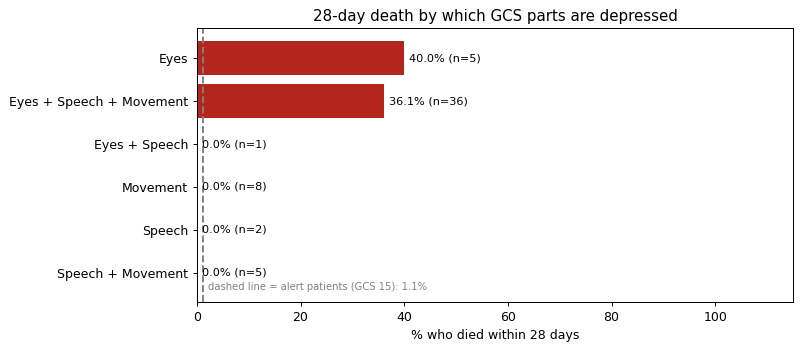

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

# Patients with depressed consciousness (GCS < 15) and which GCS parts are below normal
imp = df[df["gcs"] < 15].copy()
imp["Eyes"] = imp["eye_opening"] < 4          # normal = 4
imp["Speech"] = imp["verbal_response"] < 5    # normal = 5
imp["Movement"] = imp["movement"] < 6         # normal = 6
imp["pattern"] = imp[["Eyes", "Speech", "Movement"]].apply(lambda r: " + ".join(r.index[r]), axis=1)
imp["ventilated"] = imp["respiratory_support"].notna().astype(int)
imp["icu"] = ((imp["admission_ward"] == "ICU") | (imp["discharge_department"] == "ICU")).astype(int)
imp["gcs_band"] = pd.cut(imp["gcs"], [2, 8, 12, 14], labels=["GCS 3-8", "GCS 9-12", "GCS 13-14"])

by_pattern = imp.groupby("pattern").agg(patients=("patient_id", "size"), died_28d=("death_28d", "sum"),
                                        ventilated=("ventilated", "sum"), in_icu=("icu", "sum"))
by_pattern["death_28d_%"] = (by_pattern["died_28d"] / by_pattern["patients"] * 100).round(1)
by_pattern = by_pattern.sort_values("death_28d_%", ascending=False)
by_band = imp.groupby("gcs_band", observed=True).agg(patients=("patient_id", "size"), died_28d=("death_28d", "sum"), ventilated=("ventilated", "sum"))
by_band["death_28d_%"] = (by_band["died_28d"] / by_band["patients"] * 100).round(1)
alert_death = round(df.loc[df["gcs"] == 15, "death_28d"].mean() * 100, 1)
print("28-day death in fully alert patients (GCS 15):", alert_death, "%")
print(by_pattern.to_string()); print(); print(by_band.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(by_pattern.index, by_pattern["death_28d_%"], color="#B3261E")
for i, (r, n) in enumerate(zip(by_pattern["death_28d_%"], by_pattern["patients"])):
    ax.text(r + 1, i, f"{r}% (n={n})", va="center", fontsize=9)
ax.axvline(alert_death, color="grey", ls="--"); ax.text(alert_death + 1, len(by_pattern) - 0.6, f"dashed line = alert patients (GCS 15): {alert_death}%", fontsize=8, color="grey")
ax.set_xlabel("% who died within 28 days"); ax.set_title("28-day death by which GCS parts are depressed")
ax.invert_yaxis(); ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is one pattern of depressed GCS parts. The bar length is the % of those patients who died within 28 days; n is the number of patients. The dashed grey line is the death rate of fully alert patients, for comparison.

### Key Insights
* Only 57 patients (2.8%) arrived with GCS < 15, but **52.6%** of those with **GCS 3–8** died within 28 days, versus **1.1%** of alert patients.
* The most common pattern is **all three parts depressed** (36 patients): **36.1%** died and 25 needed ventilation, yet only 4 were cared for in ICU.
* Patients with **only movement** or **only speech** depressed had **no deaths**; this pattern points to a local brain problem (e.g. stroke) rather than failing circulation.
* Groups are small (5–36 patients), so exact percentages are rough.

### Prescriptive Action to be taken
* **Transfer immediately to the intensive cardiac care unit** when **GCS ≤ 8**, or when **eyes, speech and movement are all depressed** (any total below 15).
* A single depressed part (movement or speech only) → urgent **neurology/stroke review** rather than automatic cardiac ICU transfer.
* Record all three GCS parts at admission, not just the total.

## 2. Among patients with the "Both" (biventricular) heart failure type, does adding kidney function markers (creatinine, glomerular_filtration_rate) sharpen risk stratification — should nephrology co-management be triggered when both cardiac and renal markers are abnormal together (the "cardio-renal" pattern)?
### Reasoning
When both sides of the heart fail, the kidneys receive less blood and the body holds more fluid. Heart and kidney damage then worsen each other (the cardio-renal syndrome). If patients with both problems do much worse, that combination is a clear trigger for joint cardiology–nephrology care.

### Metrics Biomarkers and Features used
`heart_failure_type` = Both, `severe_hf` (Team05 flag: NYHA ≥ 3 and Killip ≥ 3), `glomerular_filtration_rate` (< 60 = kidney impairment), `creatinine`, `death_6m`, `readmission_6m`

### Why used
`severe_hf` summarises cardiac severity; eGFR is the standard kidney-function measure (creatinine is shown as support). 6-month death and readmission capture both danger and workload.

6-month death:
                    patients  events  rate_%
group                                       
1 Neither                625       9     1.4
2 Cardiac only           136       5     3.7
3 Kidney only            527      11     2.1
4 Cardiac + kidney       145      21    14.5

6-month readmission:
                    patients  events  rate_%
group                                       
1 Neither                625     229    36.6
2 Cardiac only           136      54    39.7
3 Kidney only            527     262    49.7
4 Cardiac + kidney       145      64    44.1

Median creatinine by group: {'1 Neither': 66.0, '2 Cardiac only': 69.0, '3 Kidney only': 128.0, '4 Cardiac + kidney': 134.0}


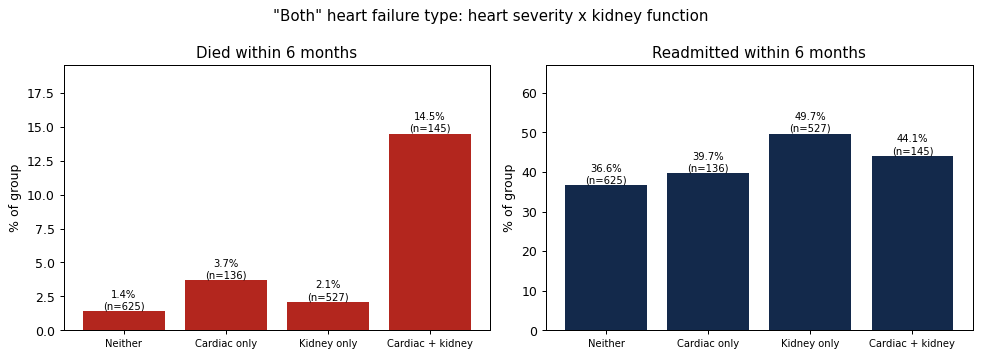

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

both = df[df["heart_failure_type"] == "Both"].copy()
both = both[both["glomerular_filtration_rate"].notna()]
cardiac_bad = both["severe_hf"] == 1                        # Team05 flag: NYHA >= 3 and Killip >= 3
renal_bad = both["glomerular_filtration_rate"] < 60          # moderate or worse kidney impairment
both["group"] = np.select([~cardiac_bad & ~renal_bad, cardiac_bad & ~renal_bad, ~cardiac_bad & renal_bad, cardiac_bad & renal_bad],
                          ["1 Neither", "2 Cardiac only", "3 Kidney only", "4 Cardiac + kidney"], "")
death = rate_table(both, "group", "death_6m"); readm = rate_table(both, "group", "readmission_6m")
print("6-month death:"); print(death); print("\n6-month readmission:"); print(readm)
print("\nMedian creatinine by group:", both.groupby("group")["creatinine"].median().round(0).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 6 months", "#B3261E"), (ax[1], readm, "Readmitted within 6 months", "#13294B")]:
    b = a.bar(t.index.str[2:], t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35); a.tick_params(axis="x", labelsize=8)
fig.suptitle('"Both" heart failure type: heart severity x kidney function')
plt.tight_layout()
plt.show()

### How to read the chart
Two bar charts share the same four groups. Left: % who died within 6 months. Right: % readmitted within 6 months. n under each % is the number of patients in the group.

### Key Insights
* In "Both" heart failure, patients with **severe HF and eGFR < 60** had **14.5%** 6-month death, about **10× higher** than patients with neither problem (1.4%).
* Either problem alone raised death only slightly (cardiac only 3.7%, kidney only 2.1%): the **combination** is what matters.
* Readmission is highest with **kidney impairment** (49.7% kidney only, 44.1% both) vs 36.6% with neither.

### Prescriptive Action to be taken
* **Trigger nephrology co-management** for "Both"-type patients who have **severe HF (`severe_hf` = 1) and eGFR < 60** at the same time.
* For patients with kidney impairment alone, add a **kidney-function and weight check within 2 weeks of discharge** to reduce readmission.

## 3. Are patients with both high d_dimer and elevated troponin (suggesting combined clotting risk + cardiac injury) more likely to be readmitted within 6 months — should this lab combination prompt anticoagulation review at discharge?
### Reasoning
D-dimer rises when the body forms and breaks down clots; troponin rises when heart muscle is damaged. Together they could point to clots affecting the heart or lungs. If this pair predicted readmission, an anticoagulation review at discharge could help.

### Metrics Biomarkers and Features used
`d_dimer` (mg/L), `high_sensitivity_troponin` (pg/mL), both split at the cohort median; `readmission_6m`, `death_6m`

### Why used
The textbook cut-offs flag almost every HF patient as abnormal, so they cannot separate risk. Splitting at the median compares the higher half with the lower half.

High = above the cohort median: D-dimer > 1.07 mg/L, troponin > 38.0 pg/mL
Patients with both tests available: 1344 of 2008
Values removed by the cleaning cap (D-dimer > 5.5 or troponin > 140): 664 patients missing at least one of the two

6-month readmission:
                 patients  events  rate_%
group                                    
1 Neither high        399     137    34.3
2 D-dimer only        281      95    33.8
3 Troponin only       278     132    47.5
4 Both high           386     161    41.7

6-month death:
                 patients  events  rate_%
group                                    
1 Neither high        399       3     0.8
2 D-dimer only        281       3     1.1
3 Troponin only       278       7     2.5
4 Both high           386      11     2.8


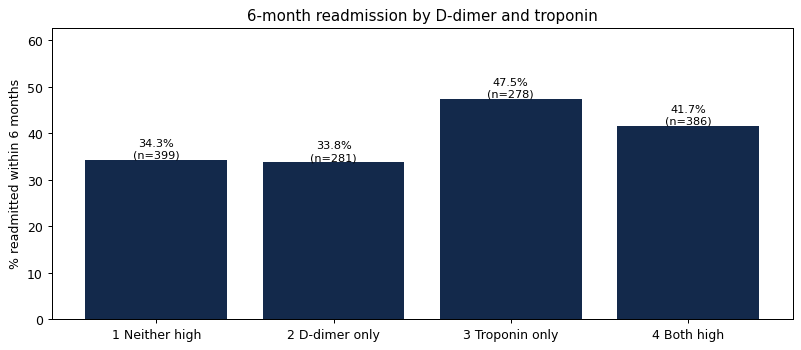

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

lab = df[df["d_dimer"].notna() & df["high_sensitivity_troponin"].notna()].copy()
dd_cut, trop_cut = lab["d_dimer"].median(), lab["high_sensitivity_troponin"].median()
print(f"High = above the cohort median: D-dimer > {dd_cut} mg/L, troponin > {trop_cut} pg/mL")
# (the textbook cut-offs, D-dimer > 0.5 and troponin > 14, flag almost every HF patient, so they cannot separate risk)
high_dd = lab["d_dimer"] > dd_cut
high_trop = lab["high_sensitivity_troponin"] > trop_cut
lab["group"] = np.select([~high_dd & ~high_trop, high_dd & ~high_trop, ~high_dd & high_trop, high_dd & high_trop],
                         ["1 Neither high", "2 D-dimer only", "3 Troponin only", "4 Both high"], "")
readm = rate_table(lab, "group", "readmission_6m"); death = rate_table(lab, "group", "death_6m")
print("Patients with both tests available:", len(lab), "of", len(df))
print("Values removed by the cleaning cap (D-dimer > 5.5 or troponin > 140):",
      int(((df["d_dimer"].isna()) | (df["high_sensitivity_troponin"].isna())).sum()), "patients missing at least one of the two")
print("\n6-month readmission:"); print(readm); print("\n6-month death:"); print(death)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(readm.index.astype(str), readm["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(readm["rate_%"], readm["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month readmission by D-dimer and troponin")
ax.set_ylabel("% readmitted within 6 months")
ax.set_ylim(0, max(readm["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is one lab combination. The height is the % readmitted within 6 months; n is the number of patients. Compare each bar with "Neither high".

### Key Insights
* **Both high** had 41.7% 6-month readmission vs 34.3% with neither, but **troponin alone** was even higher (47.5%). **D-dimer alone added nothing** (33.8%).
* So the signal comes from **troponin (heart injury)**, not from the clotting marker.
* **Data caveat:** only 1344 of 2,008 patients have both values. The cleaning removed D-dimer above 5.5 mg/L and troponin above 140 pg/mL, so the highest-risk patients are missing from this comparison.

### Prescriptive Action to be taken
* **Do not use the D-dimer + troponin pair as an anticoagulation trigger**: the data does not support it. Review anticoagulation by the usual indications (atrial fibrillation, confirmed clot).
* Treat **raised troponin** as a readmission-risk flag → early follow-up visit.

## 4. Do patients with severe heart failure (severe_hf flag) combined with elevated pulmonary pressure (pulmonary_pressure) show a distinct readmission pattern that would justify pre-discharge pulmonary pressure monitoring as a standard check before sending patients home?
### Reasoning
High pressure in the lung arteries (from the echo) shows that blood is backing up behind a failing heart. If severe HF plus high lung pressure predicted readmission, measuring it before discharge would be worthwhile.

### Metrics Biomarkers and Features used
`severe_hf`, `pulmonary_pressure` (mmHg; > 35 suggests pulmonary hypertension), `readmission_6m`, `readmission_28d`

### Why used
These are the two readmission windows used in the study; the 35 mmHg cut-off is the common echo threshold for raised lung pressure.

Patients with pulmonary pressure measured: 182 of 2008

6-month readmission:
                               patients  events  rate_%
group                                                  
1 Not severe, normal pressure        73      28    38.4
2 Not severe, high pressure          66      24    36.4
3 Severe HF, normal pressure         28      11    39.3
4 Severe HF, high pressure           15       5    33.3

28-day readmission:
                               patients  events  rate_%
group                                                  
1 Not severe, normal pressure        73       7     9.6
2 Not severe, high pressure          66       5     7.6
3 Severe HF, normal pressure         28       1     3.6
4 Severe HF, high pressure           15       0     0.0


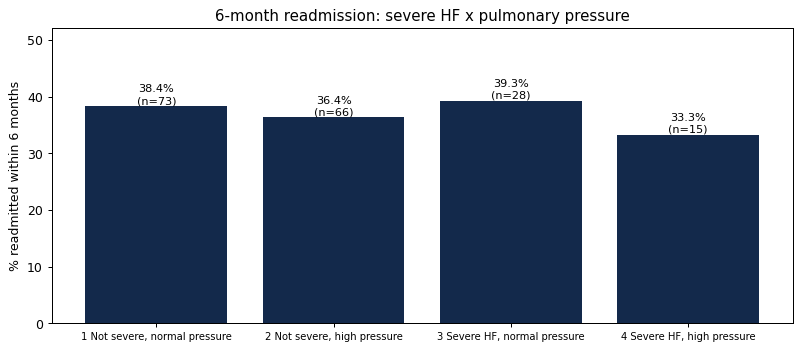

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

pp = df[df["pulmonary_pressure"].notna()].copy()
high_pp = pp["pulmonary_pressure"] > 35                 # mmHg, above this suggests pulmonary hypertension
pp["group"] = np.select([(pp["severe_hf"] == 0) & ~high_pp, (pp["severe_hf"] == 0) & high_pp, (pp["severe_hf"] == 1) & ~high_pp, (pp["severe_hf"] == 1) & high_pp],
                        ["1 Not severe, normal pressure", "2 Not severe, high pressure", "3 Severe HF, normal pressure", "4 Severe HF, high pressure"], "")
r6 = rate_table(pp, "group", "readmission_6m"); r28 = rate_table(pp, "group", "readmission_28d")
print("Patients with pulmonary pressure measured:", len(pp), "of", len(df))
print("\n6-month readmission:"); print(r6); print("\n28-day readmission:"); print(r28)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(r6.index.astype(str), r6["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(r6["rate_%"], r6["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month readmission: severe HF x pulmonary pressure")
ax.set_ylabel("% readmitted within 6 months")
ax.set_ylim(0, max(r6["rate_%"]) * 1.3 + 1)
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is one combination of HF severity and lung pressure. The height is the % readmitted within 6 months; n is the number of patients.

### Key Insights
* Pulmonary pressure was measured for only **182 of 2,008 patients** (9%).
* 6-month readmission was **similar in all four groups** (33.3–39.3%). Severe HF with high pressure was not higher (33.3%, only 15 patients).
* There is **no distinct readmission pattern** in this data.

### Prescriptive Action to be taken
* **Do not make pre-discharge pulmonary-pressure measurement a standard check** for everyone: this data gives no evidence it identifies who will return.
* Keep echo-based pressure checks for patients with clinical signs of right-heart strain, and focus discharge checks on markers that do predict readmission (kidney function, comorbidity, sodium; see questions 2, 18, 24).

## 5. Among patients with impaired consciousness at admission, which specific GCS component (eye_opening, verbal_response, or movement) combined with abnormal liver function (total_bilirubin, ALP) most strongly predicts poor outcome — is hepatic encephalopathy an under-recognized driver of "confusion" in this cohort?
### Reasoning
A failing heart can congest the liver; a very sick liver can cause confusion (hepatic encephalopathy). If confused patients with abnormal liver tests did much worse, liver-related confusion could be under-recognised.

### Metrics Biomarkers and Features used
`gcs` < 15, `eye_opening`, `verbal_response`, `movement`, `total_bilirubin` (> 21 µmol/L), `ALP` (> 125 U/L), `liver_disease`, `death_6m`

### Why used
Bilirubin and ALP are the routine liver tests in this data; 6-month death is the clearest "poor outcome".

Impaired patients: 57 | with abnormal liver tests: 27 | recorded liver disease: 3
GCS part depressed                liver  patients  died_6m  death_6m_%
       eye_opening Liver tests abnormal        21        7        33.3
       eye_opening   Liver tests normal        21        9        42.9
   verbal_response Liver tests abnormal        19        5        26.3
   verbal_response   Liver tests normal        25        9        36.0
          movement Liver tests abnormal        20        6        30.0
          movement   Liver tests normal        29        9        31.0

                      size  sum      mean
liver_abnormal                           
Liver tests abnormal    27    8  0.296296
Liver tests normal      30    9  0.300000


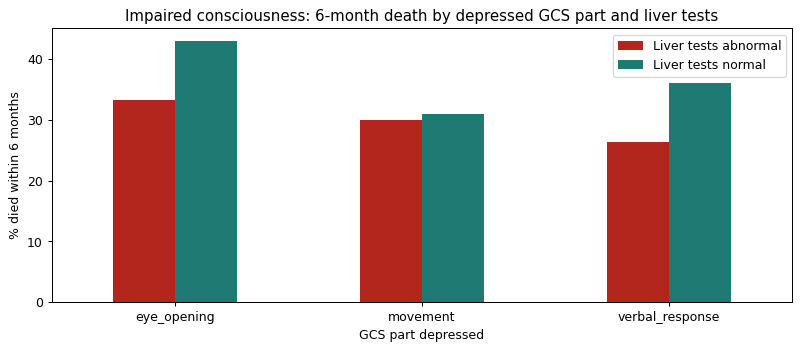

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

imp = df[df["gcs"] < 15].copy()
# Abnormal liver tests: bilirubin > 21 umol/L or ALP > 125 U/L
imp["liver_abnormal"] = ((imp["total_bilirubin"] > 21) | (imp["ALP"] > 125)).map({True: "Liver tests abnormal", False: "Liver tests normal"})
rows = []
for comp, normal in [("eye_opening", 4), ("verbal_response", 5), ("movement", 6)]:
    low = imp[imp[comp] < normal]
    for liver, g in low.groupby("liver_abnormal"):
        rows.append({"GCS part depressed": comp, "liver": liver, "patients": len(g), "died_6m": int(g["death_6m"].sum()),
                     "death_6m_%": round(g["death_6m"].mean() * 100, 1)})
table = pd.DataFrame(rows)
print("Impaired patients:", len(imp), "| with abnormal liver tests:", (imp["liver_abnormal"] == "Liver tests abnormal").sum(),
      "| recorded liver disease:", int(imp["liver_disease"].sum()))
print(table.to_string(index=False))
overall = imp.groupby("liver_abnormal")["death_6m"].agg(["size", "sum", "mean"]); print(); print(overall)

pivot = table.pivot(index="GCS part depressed", columns="liver", values="death_6m_%")
ax = pivot.plot.bar(figsize=(9, 4), color=["#B3261E", "#1F7A74"], rot=0)
ax.set_ylabel("% died within 6 months"); ax.set_title("Impaired consciousness: 6-month death by depressed GCS part and liver tests")
ax.legend(title=None)
plt.tight_layout()
plt.show()

### How to read the chart
Groups of bars, one group per depressed GCS part. Red = abnormal liver tests, teal = normal liver tests. The height is the % who died within 6 months. If liver problems mattered, red bars would be clearly taller.

### Key Insights
* 57 patients had impaired consciousness; 27 had abnormal liver tests, but only 3 had recorded liver disease.
* 6-month death was the **same with or without abnormal liver tests** (29.6% vs 30.0%), and for every GCS part the red bar is **not taller** than the teal bar.
* The data **does not support** hepatic encephalopathy as a hidden driver of confusion here; the liver changes most likely reflect congestion from the failing heart. Numbers are small, so this is a weak conclusion.

### Prescriptive Action to be taken
* Treat impaired consciousness in HF first as a **heart/oxygen emergency** (see question 1).
* Check ammonia and liver function only when there is known liver disease or clear signs of liver failure; do not delay cardiac treatment for it.

## 6. What combination of admission-day vitals (pulse, respiration, SBP, DBP) and lab values is associated with safe early discharge (low discharge_day) without increased 28-day readmission risk?
### Reasoning
Shorter stays free beds, but only if patients do not bounce back. A simple admission checklist of normal vital signs and labs may identify who can safely go home early.

### Metrics Biomarkers and Features used
`pulse` (50–100), `resp` (≤ 22), `sbp` (≥ 100), `dbp` (≥ 60), `sodium` (≥ 135), `glomerular_filtration_rate` (≥ 60) → a 0–6 checklist score; `discharge_day` (early = ≤ 7 days); `readmission_28d`

### Why used
These are the routine admission vitals plus two labs (sodium, kidney function) linked to readmission elsewhere in this analysis. 28-day readmission is the standard "was the discharge safe?" measure.

Discharged alive: 1890 | median stay: 8.0 days
                   patients  events  rate_%
early_discharge                            
Early (<= 7 days)       891      58     6.5
Later (> 7 days)        999      74     7.4

                                patients  readmitted  rate_%
stability    early_discharge                                
0-3 normal   Early (<= 7 days)        61           9    14.8
             Later (> 7 days)         86          12    14.0
4 normal     Early (<= 7 days)       146           7     4.8
             Later (> 7 days)        228          26    11.4
5 normal     Early (<= 7 days)       357          29     8.1
             Later (> 7 days)        407          25     6.1
all 6 normal Early (<= 7 days)       327          13     4.0
             Later (> 7 days)        278          11     4.0


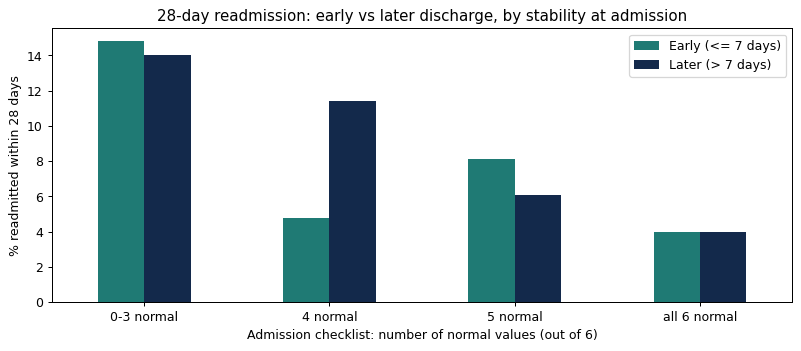

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

d = df[df["hospitalization_outcome"] == "Alive"].copy()          # discharged alive (excludes deaths and self-discharge)
d["early_discharge"] = np.where(d["discharge_day"] <= 7, "Early (<= 7 days)", "Later (> 7 days)")
# Stable-at-admission checklist: 1 point for each normal value
d["stable_score"] = ((d["pulse"].between(50, 100)).astype(int) + (d["resp"] <= 22).astype(int) + (d["sbp"] >= 100).astype(int)
                     + (d["dbp"] >= 60).astype(int) + (d["sodium"] >= 135).astype(int) + (d["glomerular_filtration_rate"] >= 60).astype(int))
d["stability"] = pd.cut(d["stable_score"], [-1, 3, 4, 5, 6], labels=["0-3 normal", "4 normal", "5 normal", "all 6 normal"])
table = d.groupby(["stability", "early_discharge"], observed=True)["readmission_28d"].agg(patients="size", readmitted="sum")
table["rate_%"] = (table["readmitted"] / table["patients"] * 100).round(1)
print("Discharged alive:", len(d), "| median stay:", d["discharge_day"].median(), "days")
print(rate_table(d, "early_discharge", "readmission_28d")); print(); print(table)

pivot = table["rate_%"].unstack()
ax = pivot.plot.bar(figsize=(9, 4), color=["#1F7A74", "#13294B"], rot=0)
ax.set_ylabel("% readmitted within 28 days"); ax.set_xlabel("Admission checklist: number of normal values (out of 6)")
ax.set_title("28-day readmission: early vs later discharge, by stability at admission"); ax.legend(title=None)
plt.tight_layout()
plt.show()

### How to read the chart
Pairs of bars, one pair per checklist score. Teal = discharged within 7 days, navy = discharged later. The height is the % readmitted within 28 days. If early discharge were unsafe, teal bars would be taller than navy bars.

### Key Insights
* Overall, early discharge did **not** increase 28-day readmission (early 6.5% vs later 7.4%).
* Patients with **at least 4 of the 6 values normal** did as well or better going home early (all 6 normal: 4.0% early vs 4.0% later; 4 normal: 4.8% vs 11.4%).
* Patients with **3 or fewer normal values** had about **15% readmission whatever their stay length**, roughly 3× the rate of the most stable group.

### Prescriptive Action to be taken
* Use the **6-item admission checklist**: patients with **≥ 4 normal values** (pulse 50–100, resp ≤ 22, SBP ≥ 100, DBP ≥ 60, sodium ≥ 135, eGFR ≥ 60) can be considered for **discharge within 7 days**.
* Patients with **≤ 3 normal values** need a stronger discharge plan (early review within 7 days) rather than a longer stay; staying longer did not lower their readmission.

## 7. Which patient profile (by admission type, department, and severity markers) should be prioritized for the 28-day in-person follow-up visit vs. the telephone-call alternative used in this study's protocol?
### Reasoning
In-person visits cost more than phone calls, so they should go to patients most likely to be readmitted or die within 28 days.

### Metrics Biomarkers and Features used
`admission_type`, `discharge_department`, `severe_hf`, `readmission_28d`, `death_28d` (combined as a 28-day event), patients discharged alive

### Why used
These three fields are known at discharge, so they can be used to book the right follow-up before the patient leaves.

Average 28-day event rate (readmission or death): 7.4 %
                                                patients  events  event_28d_%        follow_up
admission_type discharge_department severity                                                  
Emergency      Cardiology           Severe HF        154      16         10.4  In-person visit
NonEmergency   Others               Not severe        30       3         10.0  In-person visit
               Cardiology           Severe HF        150      12          8.0  In-person visit
Emergency      Cardiology           Not severe       573      46          8.0  In-person visit
               GeneralWard          Not severe       131      10          7.6  In-person visit
NonEmergency   Cardiology           Not severe       746      45          6.0   Telephone call
               GeneralWard          Not severe        59       3          5.1   Telephone call
Emergency      GeneralWard          Severe HF         23       1          4.3   Telephone

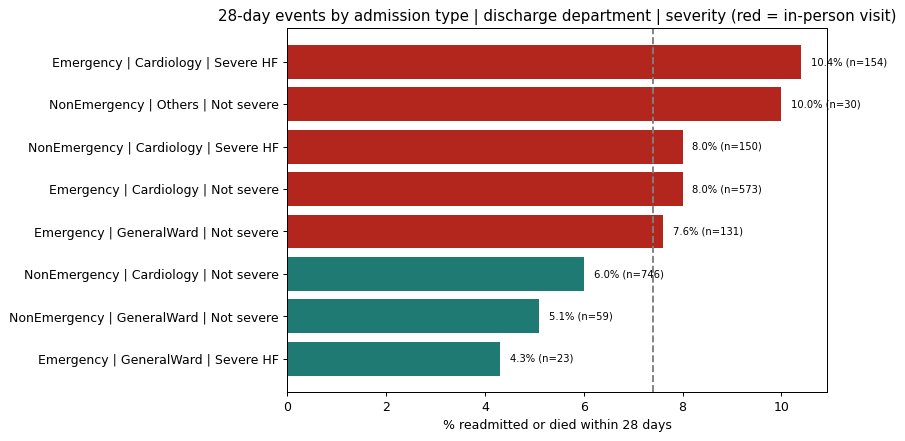

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

alive = df[df["hospitalization_outcome"] == "Alive"].copy()
alive["event_28d"] = ((alive["readmission_28d"] == 1) | (alive["death_28d"] == 1)).astype(int)   # readmitted or died within 28 days
alive["severity"] = np.where(alive["severe_hf"] == 1, "Severe HF", "Not severe")
profile = alive.groupby(["admission_type", "discharge_department", "severity"]).agg(patients=("patient_id", "size"), events=("event_28d", "sum"))
profile = profile[profile["patients"] >= 20]
profile["event_28d_%"] = (profile["events"] / profile["patients"] * 100).round(1)
avg = round(alive["event_28d"].mean() * 100, 1)
profile["follow_up"] = np.where(profile["event_28d_%"] > avg, "In-person visit", "Telephone call")
profile = profile.sort_values("event_28d_%", ascending=False)
print("Average 28-day event rate (readmission or death):", avg, "%"); print(profile.to_string())

labels = [" | ".join(i) for i in profile.index]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, profile["event_28d_%"], color=np.where(profile["event_28d_%"] > avg, "#B3261E", "#1F7A74"))
for i, (r, n) in enumerate(zip(profile["event_28d_%"], profile["patients"])):
    ax.text(r + 0.2, i, f"{r}% (n={n})", va="center", fontsize=8)
ax.axvline(avg, color="grey", ls="--"); ax.set_xlabel("% readmitted or died within 28 days")
ax.set_title("28-day events by admission type | discharge department | severity (red = in-person visit)"); ax.invert_yaxis()
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is one patient profile (admission type | discharge department | severity). The length is the % who were readmitted or died within 28 days. Red bars are above the dashed average line → in-person visit; teal bars are below → telephone call. n is the number of patients.

### Key Insights
* The average 28-day event rate was **7.4%**.
* Highest risk: **Emergency admission, Cardiology, Severe HF** (10.4%), followed by NonEmergency / Others / Not severe (10.0%), NonEmergency / Cardiology / Severe HF (8.0%).
* **Non-emergency, not-severe** patients from Cardiology or the General Ward were below average (6.0% and 5.1%).
* Differences are modest (about 4–10%), so profiles should guide, not replace, clinical judgement.

### Prescriptive Action to be taken
* **In-person 28-day visit:** emergency admissions (especially with severe HF) and anyone flagged `severe_hf` = 1.
* **Telephone call:** non-emergency admissions without severe HF, with escalation to a visit if the call finds weight gain or breathlessness.

## 8. Which combination of heart failure medications should be recommended for diabetic patients to prevent acute kidney injury?
### Reasoning
Diabetes damages the kidneys, and several HF drugs (ACE inhibitors/ARBs, MRAs, diuretics) affect kidney function and potassium. We look at which drug combinations diabetic patients received and how their kidneys were doing.

### Metrics Biomarkers and Features used
`diabetes`, drug flags for ACEi/ARB (`drug_Benazepril_...`, `drug_Valsartan_...`), MRA (`drug_Spironolactone_Tablet`), loop diuretics; `glomerular_filtration_rate`, `potassium`, `acute_renal_failure`, `death_6m`

### Why used
eGFR and potassium are the two safety checks doctors use before and after starting these drugs.

Diabetic patients: 466 | recorded acute renal failure: 2 | non-diabetic median eGFR: 66.0 | diabetic median eGFR: 59.0
                patients  median_eGFR  eGFR_below_60_pct  potassium_above_5_5_pct  loop_diuretic_pct  death_6m_pct
regimen                                                                                                           
ACEi/ARB + MRA       166         70.0               41.6                      5.4               98.2           0.6
ACEi/ARB only          6         60.0               50.0                     16.7               83.3           0.0
MRA only             253         55.0               52.2                      5.1               98.0           4.3
Neither               41         30.0               61.0                      7.3               82.9           2.4


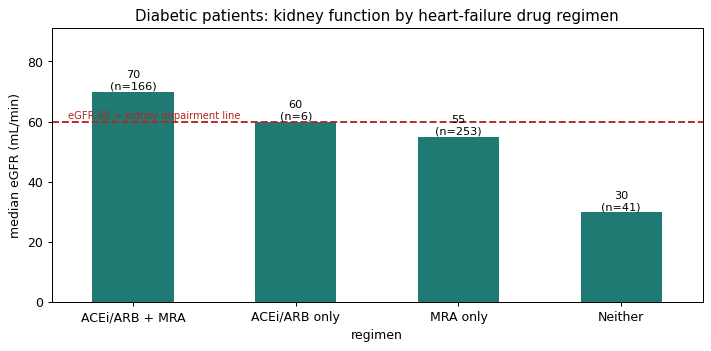

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

dm = df[df["diabetes"] == 1].copy()
acei_arb = (dm["drug_Benazepril_Hydrochloride_Tablet"] + dm["drug_Valsartan_Dispersible_Tablet"]) > 0
mra = dm["drug_Spironolactone_Tablet"] == 1
dm["regimen"] = np.select([acei_arb & mra, acei_arb & ~mra, ~acei_arb & mra], ["ACEi/ARB + MRA", "ACEi/ARB only", "MRA only"], "Neither")
dm["loop_diuretic"] = ((dm["drug_Furosemide_Injection"] + dm["drug_Furosemide_Tablet"] + dm["drug_Torasemide_Tablet"]) > 0).astype(int)
table = dm.groupby("regimen").agg(patients=("patient_id", "size"),
                                  median_eGFR=("glomerular_filtration_rate", "median"),
                                  eGFR_below_60_pct=("glomerular_filtration_rate", lambda s: round((s < 60).mean() * 100, 1)),
                                  potassium_above_5_5_pct=("potassium", lambda s: round((s > 5.5).mean() * 100, 1)),
                                  loop_diuretic_pct=("loop_diuretic", lambda s: round(s.mean() * 100, 1)),
                                  death_6m_pct=("death_6m", lambda s: round(s.mean() * 100, 1)))
table["median_eGFR"] = table["median_eGFR"].round(0)
print("Diabetic patients:", len(dm), "| recorded acute renal failure:", int(dm["acute_renal_failure"].sum()),
      "| non-diabetic median eGFR:", round(df.loc[df["diabetes"] == 0, "glomerular_filtration_rate"].median(), 0),
      "| diabetic median eGFR:", round(dm["glomerular_filtration_rate"].median(), 0))
print(table.to_string())

ax = table["median_eGFR"].plot.bar(figsize=(8, 4), color="#1F7A74", rot=0)
for i, (v, n) in enumerate(zip(table["median_eGFR"], table["patients"])):
    ax.text(i, v, f"{v:.0f}\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.axhline(60, color="#B3261E", ls="--"); ax.text(-0.4, 61, "eGFR 60 = kidney impairment line", fontsize=8, color="#B3261E")
ax.set_ylabel("median eGFR (mL/min)"); ax.set_title("Diabetic patients: kidney function by heart-failure drug regimen"); ax.set_ylim(0, table["median_eGFR"].max() * 1.3)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is one drug regimen among diabetic patients. The height is the median kidney function (eGFR); higher is better. The red dashed line at 60 marks kidney impairment. n is the number of patients.

### Key Insights
* Diabetic patients have worse kidneys than non-diabetics (median eGFR 59 vs 66).
* Patients on **ACEi/ARB + MRA** had the best kidney function (median eGFR 70) and patients on **neither** the worst (30). Doctors **avoided these drugs when the kidneys were already poor**, so this shows who was prescribed what, not what protects the kidneys.
* Only **2** diabetic patients have acute renal failure recorded, and there is no repeat creatinine, so **this data cannot show which combination prevents acute kidney injury**.

### Prescriptive Action to be taken
* Follow the guideline combination (**beta-blocker + ACEi/ARB + MRA**, with the lowest effective diuretic dose) in diabetic HF patients whose eGFR allows it.
* **Check creatinine and potassium within 1–2 weeks** of starting or increasing ACEi/ARB or MRA; pause or reduce if potassium > 5.5 or creatinine rises sharply.
* Record creatinine at discharge and at follow-up, so kidney injury can be measured in future data.

## 9. Should patients discharged from Cardiology vs. General Ward receive different follow-up intensity, given the departmental differences in 6-month readmission rates?
### Reasoning
If one department's patients were readmitted much more often, that department might need a stronger discharge process or follow-up.

### Metrics Biomarkers and Features used
`discharge_department` (Cardiology, GeneralWard), `readmission_6m`, `death_6m`, `severe_hf`, age (`age_category`), `cci_score`

### Why used
Case-mix fields (severity, age, comorbidity) show whether any difference comes from the department or from its patients.

                      patients  events  rate_%
discharge_department                          
Cardiology                1703     665    39.0
GeneralWard                241      89    36.9

                      severe_hf_pct  age_80_plus_pct  mean_comorbidity  death_6m_pct
discharge_department                                                                
Cardiology                     19.8             34.7              1.84           2.2
GeneralWard                    14.1             52.7              1.98           2.9


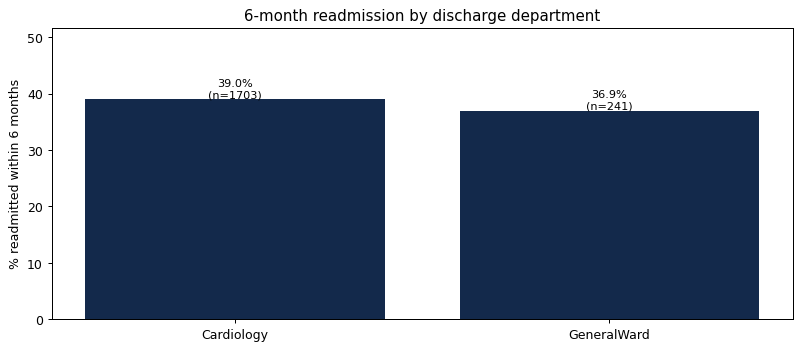

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

d = df[df["discharge_department"].isin(["Cardiology", "GeneralWard"])].copy()
readm = rate_table(d, "discharge_department", "readmission_6m")
mix = d.groupby("discharge_department").agg(severe_hf_pct=("severe_hf", lambda s: round(s.mean() * 100, 1)),
                                            age_80_plus_pct=("age_category", lambda s: round(s.isin(["79-89", "89-110"]).mean() * 100, 1)),
                                            mean_comorbidity=("cci_score", lambda s: round(s.mean(), 2)),
                                            death_6m_pct=("death_6m", lambda s: round(s.mean() * 100, 1)))
print(readm); print(); print(mix)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(readm.index.astype(str), readm["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(readm["rate_%"], readm["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month readmission by discharge department")
ax.set_ylabel("% readmitted within 6 months")
ax.set_ylim(0, max(readm["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is a discharge department. The height is the % readmitted within 6 months; n is the number of patients.

### Key Insights
* 6-month readmission was **almost the same**: Cardiology 39.0% vs General Ward 36.9%.
* General Ward patients are **older** (52.7% aged 80+ vs 34.7%) and have slightly higher 6-month death (2.9% vs 2.2%), while Cardiology discharges more severe HF (19.8% vs 14.1%).

### Prescriptive Action to be taken
* **Do not set follow-up intensity by department.** Base it on the patient's own risk (severity, kidney function, comorbidity; see questions 7 and 25).
* General Ward teams should make sure their older HF patients get the same HF discharge bundle as Cardiology patients.

## 10. Should care intensity/follow-up frequency differ by age group, given whether elderly patients (e.g., 80+) show different readmission/mortality patterns than younger patients in this cohort?
### Reasoning
Older patients are often assumed to be at higher risk. If age alone separated outcomes, follow-up could simply be scheduled by age.

### Metrics Biomarkers and Features used
`age_category` (grouped < 70, 70–79, 80+), `readmission_6m`, `death_28d`, `death_6m`, `hospitalization_outcome` (left against advice)

### Why used
These are the main outcomes that follow-up is meant to prevent.

           patients  readmission_6m  death_28d  death_6m  left_against_advice
age_group                                                                    
<70             546            35.2        1.6       2.7                  5.5
70-79           715            41.3        1.8       2.7                  4.8
80+             747            38.3        2.0       3.1                  5.8


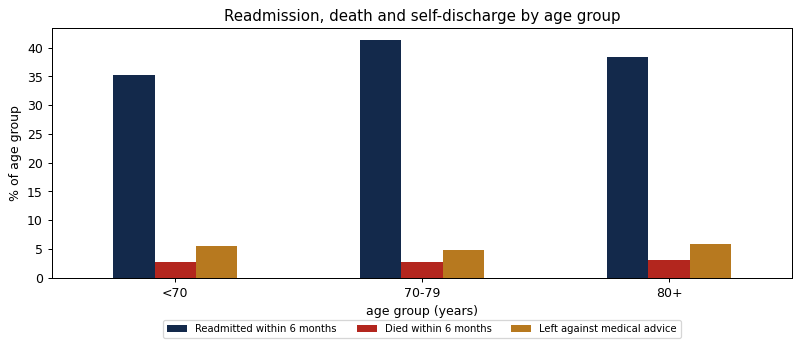

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

df["age_group"] = df["age_category"].map({"21-29": "<70", "29-39": "<70", "39-49": "<70", "49-59": "<70", "59-69": "<70",
                                          "69-79": "70-79", "79-89": "80+", "89-110": "80+"})
table = df.groupby("age_group").agg(patients=("patient_id", "size"),
                                    readmission_6m=("readmission_6m", lambda s: round(s.mean() * 100, 1)),
                                    death_28d=("death_28d", lambda s: round(s.mean() * 100, 1)),
                                    death_6m=("death_6m", lambda s: round(s.mean() * 100, 1)),
                                    left_against_advice=("hospitalization_outcome", lambda s: round((s == "DischargeAgainstOrder").mean() * 100, 1)))
table = table.reindex(["<70", "70-79", "80+"])
print(table)

ax = table[["readmission_6m", "death_6m", "left_against_advice"]].plot.bar(figsize=(9, 4), rot=0, color=["#13294B", "#B3261E", "#B7791F"])
ax.set_ylabel("% of age group"); ax.set_xlabel("age group (years)"); ax.set_title("Readmission, death and self-discharge by age group")
ax.legend(["Readmitted within 6 months", "Died within 6 months", "Left against medical advice"], loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

### How to read the chart
Groups of three bars per age group: navy = readmitted within 6 months, red = died within 6 months, amber = left hospital against medical advice. Compare the same colour across age groups.

### Key Insights
* Outcomes differ **only a little** by age: 6-month readmission 35.2% (< 70), 41.3% (70–79), 38.3% (80+); 6-month death 2.7%, 2.7%, 3.1%.
* In this elderly cohort (73% are 70+), **age alone is not a strong risk marker**; severity, kidney function and comorbidity matter more.

### Prescriptive Action to be taken
* **Do not set follow-up frequency by age alone.** Use a risk-based approach (severity, kidney function, comorbidity).
* For patients aged 80+, add practical support (carer involvement, simple medication plans), because frailty affects how well they manage at home.

## 11. Does occupation (a proxy for rural vs urban living) change readmission rates?
### Reasoning
Readmission depends on disease and also on **access**: patients living far from hospital may return less often even when unwell.

### Metrics Biomarkers and Features used
`occupation` (groups with 50+ patients), `readmission_6m`, `death_6m`

### Why used
Occupation is the only rural/urban marker in the data.

6-month readmission:
               patients  events  rate_%
occupation                             
Farmer              198      48    24.2
Urbanresident      1670     665    39.8
Others               89      38    42.7

6-month death:
               patients  events  rate_%
occupation                             
Farmer              198       8     4.0
Urbanresident      1670      46     2.8
Others               89       2     2.2


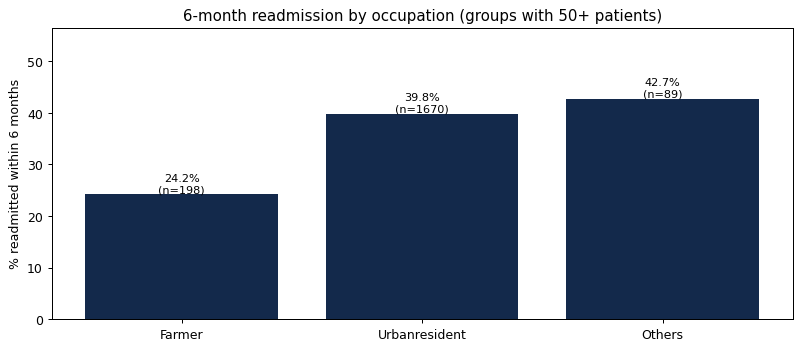

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

occ = rate_table(df, "occupation", "readmission_6m")
occ = occ[occ["patients"] >= 50].sort_values("rate_%")
death = rate_table(df, "occupation", "death_6m").loc[occ.index]
print("6-month readmission:"); print(occ); print("\n6-month death:"); print(death)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(occ.index.astype(str), occ["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(occ["rate_%"], occ["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month readmission by occupation (groups with 50+ patients)")
ax.set_ylabel("% readmitted within 6 months")
ax.set_ylim(0, max(occ["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is an occupation group. The height is the % readmitted within 6 months; n is the number of patients.

### Key Insights
* Farmers were readmitted far less often (**24.2%**) than urban residents (**39.8%**).
* Farmers are not healthier: their 6-month death was **higher** (4.0% vs 2.8%).
* The likely reason is **distance and access**: rural patients may go without care or use other hospitals, which this data cannot see.

### Prescriptive Action to be taken
* Add **telephone follow-up or remote monitoring** for rural patients.
* Do not read their low readmission rate as good outcomes.

## 12. Do echo markers of heart damage agree with each other and with BNP (ventricular remodelling)?
### Reasoning
A damaged heart gets bigger (larger ventricle) and pumps weaker (lower LVEF), and the stretched wall releases BNP. If these agree, BNP could stand in for an echo when none is available.

### Metrics Biomarkers and Features used
`heart_pumping_efficiency` (LVEF %), `left_ventricle_size` (mm), `brain_natriuretic_peptide` (BNP)

### Why used
Spearman correlation measures whether two values rise or fall together (−1 = perfectly opposite, 0 = unrelated, +1 = perfectly together); it is not distorted by extreme values.

Spearman correlation (-1 to +1):
              LVEF (%)  LV size (mm)   BNP
LVEF (%)          1.00         -0.66 -0.35
LV size (mm)     -0.66          1.00  0.26
BNP              -0.35          0.26  1.00

                 measured  median_BNP  missing_pct
hf_type                                           
HFrEF (<40%)           41      662.19         68.9
HFmrEF (40-49%)        66      488.96         56.6
HFpEF (>=50%)         271      275.54         22.8


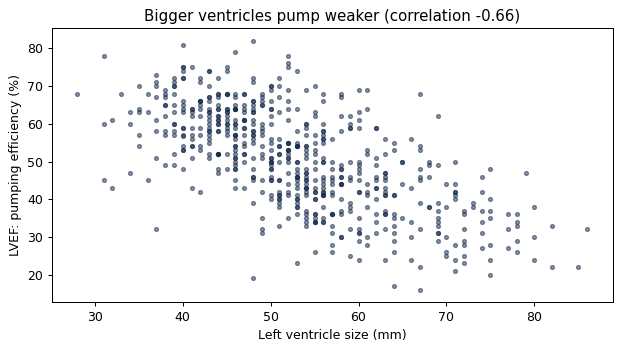

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

cols = {"heart_pumping_efficiency": "LVEF (%)", "left_ventricle_size": "LV size (mm)", "brain_natriuretic_peptide": "BNP"}
corr = df[list(cols)].rename(columns=cols).corr(method="spearman").round(2)
print("Spearman correlation (-1 to +1):"); print(corr)
echo = df[df["heart_pumping_efficiency"].notna()].copy()
echo["hf_type"] = pd.cut(echo["heart_pumping_efficiency"], [0, 40, 50, 100], right=False, labels=["HFrEF (<40%)", "HFmrEF (40-49%)", "HFpEF (>=50%)"])
bnp = echo.groupby("hf_type", observed=True)["brain_natriuretic_peptide"].agg(
    measured="count", median_BNP="median", missing_pct=lambda s: round(s.isna().mean() * 100, 1))
print(); print(bnp)

fig, ax = plt.subplots(figsize=(7, 4))
plot = df[df["left_ventricle_size"] >= 20]          # sizes below 20 mm are recording errors, left out of the picture only
ax.scatter(plot["left_ventricle_size"], plot["heart_pumping_efficiency"], s=10, alpha=0.5, color="#13294B")
ax.set_xlabel("Left ventricle size (mm)"); ax.set_ylabel("LVEF: pumping efficiency (%)")
ax.set_title(f"Bigger ventricles pump weaker (correlation {corr.iloc[0, 1]})")
plt.tight_layout()
plt.show()

### How to read the chart
Each dot is one patient with an echo (ventricle sizes below 20 mm, which are recording errors, are left out of the picture). Left to right = bigger ventricle; bottom to top = better pumping. A cloud sloping down from left to right means bigger hearts pump weaker.

### Key Insights
* Bigger ventricles clearly pump weaker (correlation **-0.66**).
* BNP agrees only **weakly** (with LVEF -0.35, with LV size 0.26).
* **Data caveat:** BNP is missing for **68.9%** of HFrEF patients, versus 22.8% of HFpEF patients. The cleaning removed every BNP above 1,000 pg/mL, exactly the values expected in weak hearts. This hides much of the true agreement.

### Prescriptive Action to be taken
* Where no echo is available, a BNP near the top of the recorded range should trigger an **urgent echo**.
* **Fix the data:** re-run the Team05 cleaning with the corrected lab Step G so that BNP values up to 5,000 pg/mL are kept, then repeat this analysis.

## 13. Do patients who never had an echo recorded do worse (a care-process gap)?
### Reasoning
Guidelines ask for an echo in every HF admission. If patients without an echo did worse, missing echoes would be a quality problem.

### Metrics Biomarkers and Features used
`heart_pumping_efficiency` present or missing (echo recorded), `death_6m`, `readmission_6m`, `hospitalization_outcome` (left against advice), `severe_hf`, `discharge_day`

### Why used
These outcomes and case-mix fields show whether the echo gap matters and whether sicker patients are the ones missing it.

echo_recorded        Echo recorded  No echo recorded
patients                     635.0            1373.0
death_6m                       1.6               3.4
readmission_6m                40.0              37.8
left_against_advice            9.3               3.5
severe_hf                     16.2              20.6
median_stay                    8.0               8.0


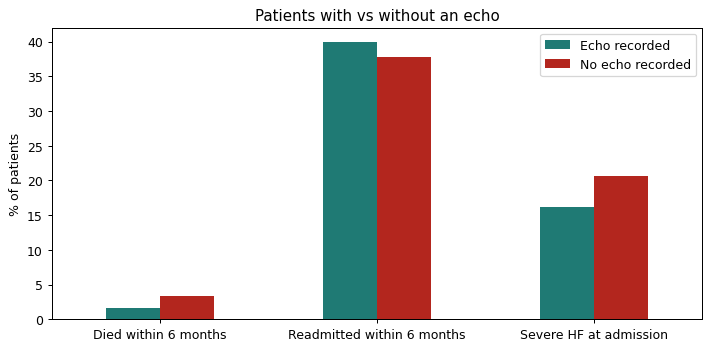

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

df["echo_recorded"] = np.where(df["heart_pumping_efficiency"].notna(), "Echo recorded", "No echo recorded")
table = df.groupby("echo_recorded").agg(patients=("patient_id", "size"),
                                        death_6m=("death_6m", lambda s: round(s.mean() * 100, 1)),
                                        readmission_6m=("readmission_6m", lambda s: round(s.mean() * 100, 1)),
                                        left_against_advice=("hospitalization_outcome", lambda s: round((s == "DischargeAgainstOrder").mean() * 100, 1)),
                                        severe_hf=("severe_hf", lambda s: round(s.mean() * 100, 1)),
                                        median_stay=("discharge_day", "median"))
print(table.T)

ax = table[["death_6m", "readmission_6m", "severe_hf"]].T.plot.bar(figsize=(8, 4), rot=0, color=["#1F7A74", "#B3261E"])
ax.set_ylabel("% of patients"); ax.set_xticklabels(["Died within 6 months", "Readmitted within 6 months", "Severe HF at admission"])
ax.set_title("Patients with vs without an echo"); ax.legend(title=None)
plt.tight_layout()
plt.show()

### How to read the chart
Pairs of bars for three measures. Teal = patients with an echo, red = patients without. Compare the two colours within each pair.

### Key Insights
* **1373 patients (68%)** have no echo recorded.
* Their 6-month death was about **twice as high** (3.4% vs 1.6%), and they were more often severe HF at admission (20.6% vs 16.2%).
* Readmission was similar (37.8% vs 40.0%). Part of the gap is **timing**: very sick patients may die before an echo is done.

### Prescriptive Action to be taken
* Perform an **echo within 48 hours** of admission, before any early death or discharge.
* Track the echo rate as a department quality indicator.

## 14. How does kidney function (eGFR stage) relate to death and readmission — is the relationship linear?
### Reasoning
The heart and kidneys depend on each other. Kidney stages (G1 best → G5 worst) show where risk starts to rise.

### Metrics Biomarkers and Features used
`glomerular_filtration_rate` → KDIGO stages G1–G5, `death_6m`, `readmission_6m`

### Why used
KDIGO stages are the standard clinical kidney groups, so the answer maps directly onto clinical thresholds.

6-month death:
              patients  events  rate_%
kidney_stage                          
G1 (90+)           491       8     1.6
G2 (60-89)         568      13     2.3
G3a (45-59)        330       5     1.5
G3b (30-44)        304       9     3.0
G4 (15-29)         176      14     8.0
G5 (<15)            76       7     9.2

6-month readmission:
              patients  events  rate_%
kidney_stage                          
G1 (90+)           491     151    30.8
G2 (60-89)         568     205    36.1
G3a (45-59)        330     147    44.5
G3b (30-44)        304     152    50.0
G4 (15-29)         176      72    40.9
G5 (<15)            76      26    34.2


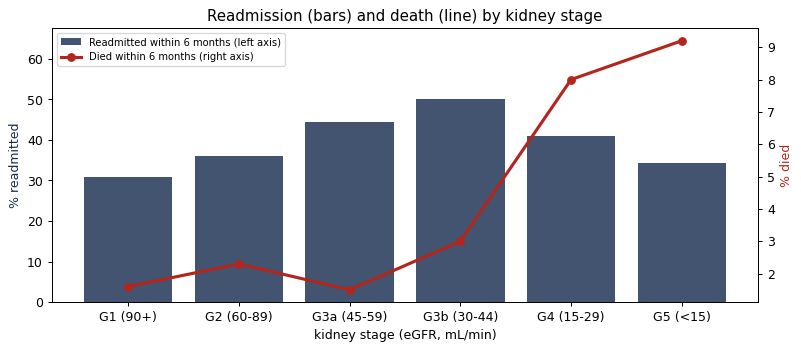

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

df["kidney_stage"] = pd.cut(df["glomerular_filtration_rate"], [0, 15, 30, 45, 60, 90, 1000], right=False,
                            labels=["G5 (<15)", "G4 (15-29)", "G3b (30-44)", "G3a (45-59)", "G2 (60-89)", "G1 (90+)"])
order = ["G1 (90+)", "G2 (60-89)", "G3a (45-59)", "G3b (30-44)", "G4 (15-29)", "G5 (<15)"]
death = rate_table(df, "kidney_stage", "death_6m").reindex(order)
readm = rate_table(df, "kidney_stage", "readmission_6m").reindex(order)
print("6-month death:"); print(death); print("\n6-month readmission:"); print(readm)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(order, readm["rate_%"], color="#13294B", alpha=0.8, label="Readmitted within 6 months (left axis)")
ax1.set_ylabel("% readmitted", color="#13294B"); ax1.set_xlabel("kidney stage (eGFR, mL/min)")
ax2 = ax1.twinx()
ax2.plot(order, death["rate_%"], color="#B3261E", marker="o", lw=2.5, label="Died within 6 months (right axis)")
ax2.set_ylabel("% died", color="#B3261E")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8); ax1.set_ylim(0, readm["rate_%"].max() * 1.35)
ax1.set_title("Readmission (bars) and death (line) by kidney stage")
plt.tight_layout()
plt.show()

### How to read the chart
Bars (left axis, navy) = % readmitted within 6 months; line (right axis, red) = % died within 6 months. Kidney function gets worse from left to right.

### Key Insights
* **Not linear.** Death stays low (about 1.6–3.0%) until eGFR drops below 30, then jumps to **8.0% (G4)** and **9.2% (G5)**.
* Readmission peaks in **moderate** kidney disease (**50.0% in G3b**) and falls in G4–G5, partly because more of those patients die.

### Prescriptive Action to be taken
* **eGFR < 30:** nephrology and palliative-care review.
* **eGFR 30–59:** early kidney-function and weight check after discharge to fine-tune diuretics.

## 15. Does cardiac injury (hs-troponin) predict death in HF, even without a heart attack?
### Reasoning
Troponin leaks from damaged heart muscle. In HF it can rise from strain alone, without a heart attack.

### Metrics Biomarkers and Features used
`high_sensitivity_troponin` (pg/mL) in quartiles, `heart_attack_history`, `death_6m`

### Why used
Quartiles (four equal groups) avoid choosing an arbitrary cut-off; the no-heart-attack subgroup tests "even without a heart attack".

Troponin range per quartile (pg/mL): {'Q1 (lowest)': {'min': 0.0, 'max': 17.0}, 'Q2': {'min': 18.0, 'max': 38.0}, 'Q3': {'min': 39.0, 'max': 72.0}, 'Q4 (highest kept)': {'min': 73.0, 'max': 140.0}, 'Removed / missing': {'min': nan, 'max': nan}}
                   patients  events  rate_%
troponin_group                             
Q1 (lowest)             384       3     0.8
Q2                      379       4     1.1
Q3                      386       6     1.6
Q4 (highest kept)       376      19     5.1
Removed / missing       483      25     5.2

Patients without a previous heart attack:
                   patients  events  rate_%
troponin_group                             
Q1 (lowest)             366       3     0.8
Q2                      361       4     1.1
Q3                      358       6     1.7
Q4 (highest kept)       356      18     5.1
Removed / missing       424      22     5.2


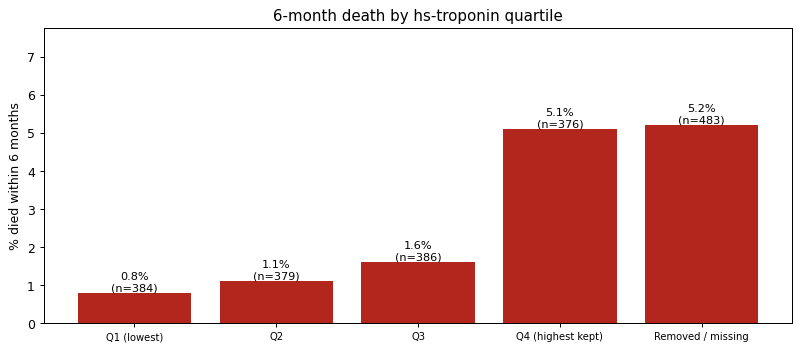

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

trop = df["high_sensitivity_troponin"]
df["troponin_group"] = pd.qcut(trop, 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest kept)"]).astype(object)
df.loc[trop.isna(), "troponin_group"] = "Removed / missing"
order = ["Q1 (lowest)", "Q2", "Q3", "Q4 (highest kept)", "Removed / missing"]
table = rate_table(df, "troponin_group", "death_6m").reindex(order)
no_mi = rate_table(df[df["heart_attack_history"] == 0], "troponin_group", "death_6m").reindex(order)
print("Troponin range per quartile (pg/mL):", df.groupby("troponin_group")["high_sensitivity_troponin"].agg(["min", "max"]).round(1).to_dict("index"))
print(table); print("\nPatients without a previous heart attack:"); print(no_mi)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(table.index.astype(str), table["rate_%"], color="#B3261E")
for b, (r, n) in zip(bars, zip(table["rate_%"], table["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month death by hs-troponin quartile")
ax.set_ylabel("% died within 6 months")
ax.set_ylim(0, max(table["rate_%"]) * 1.3 + 1)
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is a troponin group, from lowest to highest. The height is the % who died within 6 months. The last bar holds patients whose troponin was missing, mostly the values above 140 pg/mL that the cleaning removed.

### Key Insights
* Death rises from **0.8%** (lowest quartile) to **5.1%** (highest quartile kept), and the pattern is the same in patients with **no previous heart attack** (0.8% → 5.1%).
* The **removed/missing** group has the same high death rate (5.2%, 483 patients). This shows the cleaning cap removed high-risk patients, not errors.

### Prescriptive Action to be taken
* Treat troponin above about **70 pg/mL** in an HF admission as a **mortality warning**, not just "HF leak".
* Re-run the Team05 cleaning with the corrected Step G so that troponin values above 140 pg/mL are kept.

## 16. Which lab markers move together — do they form distinct biological "axes" of HF severity?
### Reasoning
If markers move together they measure the same thing; if not, each adds new information. This guides which markers to combine in a risk score.

### Metrics Biomarkers and Features used
BNP, troponin, eGFR, urea, cystatin C, haemoglobin, albumin, sodium, D-dimer, CRP (`high_sensitivity_protein`), lymphocytes

### Why used
They cover the heart, kidneys, blood, nutrition/inflammation and clotting.

              BNP  Troponin  eGFR  Urea  Cystatin C  Haemoglobin  Albumin  Sodium  D-dimer   CRP  Lymphocytes
BNP          1.00      0.37 -0.11  0.10        0.07        -0.05    -0.20    0.10     0.26  0.02        -0.04
Troponin     0.37      1.00 -0.27  0.30        0.24         0.01    -0.11   -0.15     0.21  0.13        -0.13
eGFR        -0.11     -0.27  1.00 -0.67       -0.81         0.33     0.17    0.17    -0.24 -0.11         0.15
Urea         0.10      0.30 -0.67  1.00        0.62        -0.19    -0.14   -0.26     0.21  0.14        -0.14
Cystatin C   0.07      0.24 -0.81  0.62        1.00        -0.32    -0.20   -0.22     0.19  0.19        -0.13
Haemoglobin -0.05      0.01  0.33 -0.19       -0.32         1.00     0.31    0.04    -0.13  0.06         0.30
Albumin     -0.20     -0.11  0.17 -0.14       -0.20         0.31     1.00    0.11    -0.36 -0.20         0.18
Sodium       0.10     -0.15  0.17 -0.26       -0.22         0.04     0.11    1.00    -0.08 -0.26         0.15
D-dimer   

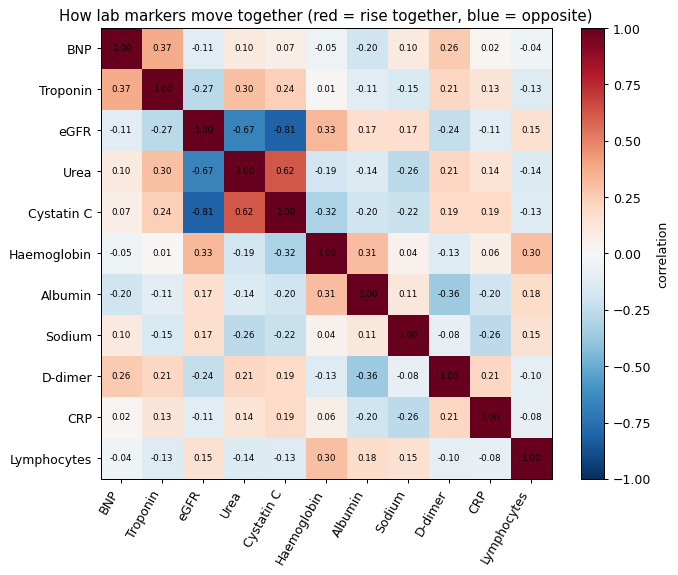

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

markers = {"brain_natriuretic_peptide": "BNP", "high_sensitivity_troponin": "Troponin", "glomerular_filtration_rate": "eGFR", "urea": "Urea",
           "cystatin": "Cystatin C", "hemoglobin": "Haemoglobin", "albumin": "Albumin", "sodium": "Sodium", "d_dimer": "D-dimer",
           "high_sensitivity_protein": "CRP", "lymphocyte_count": "Lymphocytes"}
corr = df[list(markers)].rename(columns=markers).corr(method="spearman").round(2)
print(corr)

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=60, ha="right"); ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, fraction=0.04, label="correlation"); ax.set_title("How lab markers move together (red = rise together, blue = opposite)")
plt.tight_layout()
plt.show()

### How to read the chart
A grid where each cell shows how two markers move together. **Dark red** = rise together, **dark blue** = one rises as the other falls, **white** = unrelated. The diagonal is always 1 (a marker with itself).

### Key Insights
* **Kidney axis:** eGFR, urea and cystatin C move strongly together (eGFR–cystatin -0.81, eGFR–urea -0.67).
* **Heart-strain axis:** BNP and troponin (0.37).
* **Nutrition/inflammation axis:** albumin falls as D-dimer rises (-0.36).
* Across axes the links are weak (BNP–eGFR -0.11).
* **Caveat:** BNP, troponin, D-dimer and CRP were capped by the cleaning, which weakens their correlations.

### Prescriptive Action to be taken
* Build bedside risk scores from **one marker per axis** (e.g. troponin + eGFR + albumin + sodium), not several kidney markers at once.

## 17. Does high lactate (poor tissue perfusion) identify patients at risk of early death?
### Reasoning
Lactate builds up when organs lack oxygen, as in cardiogenic shock.

### Metrics Biomarkers and Features used
`lactate` (> 2 mmol/L = high), `pH` (blood gas taken or not), `death_28d`

### Why used
Lactate is the standard marker of poor perfusion; whether a blood gas was taken shows how sick doctors judged the patient.

Among patients with lactate measured:
                      patients  events  rate_%
lactate_level                                 
High (> 2 mmol/L)          397      18     4.5
Normal (<= 2 mmol/L)       596       9     1.5

All patients:
                 patients  events  rate_%
blood_gas                                
Blood gas taken       993      27     2.7
No blood gas         1015      10     1.0


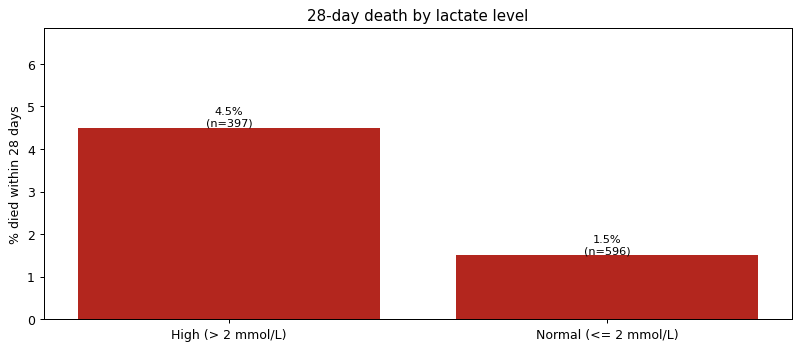

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

bg = df[df["lactate"].notna()].copy()
bg["lactate_level"] = np.where(bg["lactate"] > 2, "High (> 2 mmol/L)", "Normal (<= 2 mmol/L)")
lact = rate_table(bg, "lactate_level", "death_28d")
df["blood_gas"] = np.where(df["pH"].notna(), "Blood gas taken", "No blood gas")
gas = rate_table(df, "blood_gas", "death_28d")
print("Among patients with lactate measured:"); print(lact); print("\nAll patients:"); print(gas)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(lact.index.astype(str), lact["rate_%"], color="#B3261E")
for b, (r, n) in zip(bars, zip(lact["rate_%"], lact["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("28-day death by lactate level")
ax.set_ylabel("% died within 28 days")
ax.set_ylim(0, max(lact["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### How to read the chart
Two bars: high vs normal lactate. The height is the % who died within 28 days; n is the number of patients.

### Key Insights
* Among 993 patients with lactate measured, **high lactate** had **4.5%** 28-day death vs **1.5%**, about 3× higher.
* Simply having a blood gas taken also marked higher risk (2.7% vs 1.0%).

### Prescriptive Action to be taken
* Measure **lactate early** in HF patients with low blood pressure, cold hands/feet or confusion; lactate > 2 mmol/L → critical-care review.

## 18. Does comorbidity burden drive readmissions and longer stays?
### Reasoning
Each extra chronic disease adds another reason to return to hospital and to stay longer.

### Metrics Biomarkers and Features used
`cci_score` (grouped 0–1, 2, 3, 4+), `readmission_6m`, `discharge_day` (≥ 14 days = long stay)

### Why used
The comorbidity count summarises chronic burden in one number.

6-month readmission:
                   patients  events  rate_%
comorbidity_group                          
0-1                     826     294    35.6
2                       699     261    37.3
3                       368     155    42.1
4+                      110      61    55.5

Stay of 14+ days:
                   patients  events  rate_%
comorbidity_group                          
0-1                     826      88    10.7
2                       699      94    13.4
3                       368      64    17.4
4+                      110      25    22.7


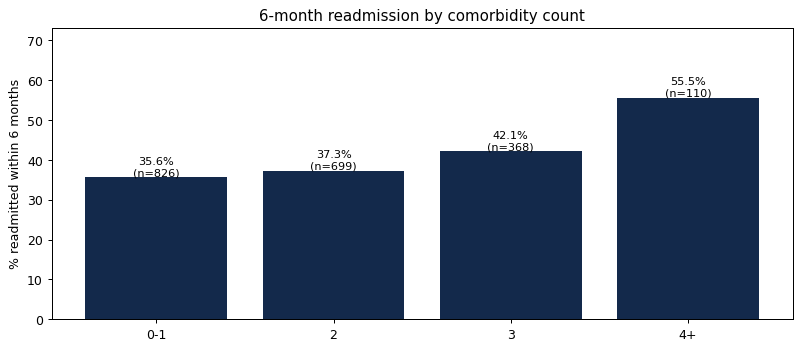

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

df["comorbidity_group"] = pd.cut(df["cci_score"], [-1, 1, 2, 3, 20], labels=["0-1", "2", "3", "4+"])
df["long_stay"] = (df["discharge_day"] >= 14).astype(int)
readm = rate_table(df, "comorbidity_group", "readmission_6m")
stay = rate_table(df, "comorbidity_group", "long_stay")
print("6-month readmission:"); print(readm); print("\nStay of 14+ days:"); print(stay)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(readm.index.astype(str), readm["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(readm["rate_%"], readm["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month readmission by comorbidity count")
ax.set_ylabel("% readmitted within 6 months")
ax.set_ylim(0, max(readm["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is a comorbidity group. The height is the % readmitted within 6 months; n is the number of patients.

### Key Insights
* Readmission climbs steadily: **35.6% → 37.3% → 42.1% → 55.5%** (4+ conditions).
* Long stays (14+ days) double: 10.7% → 22.7%.

### Prescriptive Action to be taken
* Patients with **≥ 3 comorbidities** get a multidisciplinary discharge (pharmacist review plus the relevant specialist) and a care coordinator.

## 19. Which individual comorbidities matter most, and for which outcome?
### Reasoning
The total count hides which disease drives risk. Comparing each condition shows which matters for death and which for readmission.

### Metrics Biomarkers and Features used
Comorbidity flags (CKD, diabetes, COPD, stroke, dementia, liver disease, type 2 respiratory failure, solid tumour), `death_6m`, `readmission_6m`

### Why used
"Times higher" = the rate with the condition divided by the rate without it (1 = no difference).

                            patients  death_6m_with_%  death_6m_without_%  readm_6m_with_%  readm_6m_without_%  death_times_higher  readm_times_higher
condition                                                                                                                                             
Dementia                         115              0.9                 3.0             50.4                37.8                0.30                1.33
COPD                             233              1.7                 3.0             38.2                38.5                0.57                0.99
Diabetes                         466              2.8                 2.9             45.7                36.3                0.97                1.26
Stroke                           150              4.0                 2.7             39.3                38.4                1.48                1.02
Solid tumour                      39              5.1                 2.8             35.9    

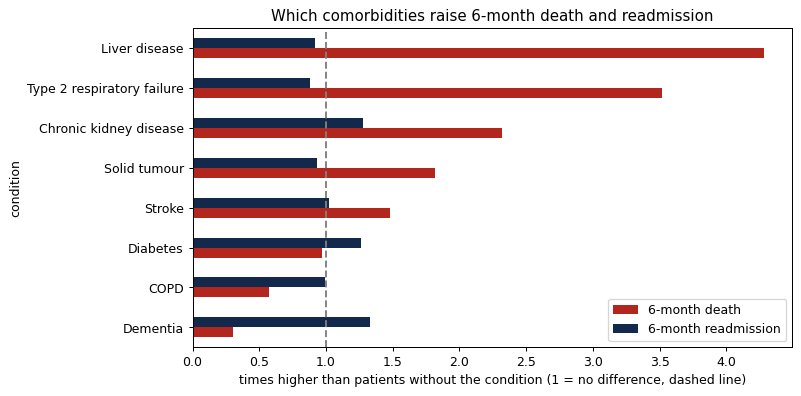

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

conditions = {"moderate_to_severe_chronic_kidney_disease": "Chronic kidney disease", "diabetes": "Diabetes",
              "chronic_obstructive_pulmonary_disease": "COPD", "cerebrovascular_disease": "Stroke", "dementia": "Dementia",
              "liver_disease": "Liver disease", "type2_respiratory_failure": "Type 2 respiratory failure", "solid_tumor": "Solid tumour"}
rows = []
for col, name in conditions.items():
    has, no = df[df[col] == 1], df[df[col] == 0]
    rows.append({"condition": name, "patients": len(has),
                 "death_6m_with_%": round(has["death_6m"].mean() * 100, 1), "death_6m_without_%": round(no["death_6m"].mean() * 100, 1),
                 "readm_6m_with_%": round(has["readmission_6m"].mean() * 100, 1), "readm_6m_without_%": round(no["readmission_6m"].mean() * 100, 1)})
t = pd.DataFrame(rows).set_index("condition")
t["death_times_higher"] = (t["death_6m_with_%"] / t["death_6m_without_%"]).round(2)
t["readm_times_higher"] = (t["readm_6m_with_%"] / t["readm_6m_without_%"]).round(2)
t = t.sort_values("death_times_higher")
print(t.to_string())

ax = t[["death_times_higher", "readm_times_higher"]].plot.barh(figsize=(9, 4.5), color=["#B3261E", "#13294B"])
ax.legend(["6-month death", "6-month readmission"], loc="lower right")
ax.axvline(1, color="grey", ls="--"); ax.set_xlabel("times higher than patients without the condition (1 = no difference, dashed line)")
ax.set_title("Which comorbidities raise 6-month death and readmission")
plt.tight_layout()
plt.show()

### How to read the chart
Each condition has two bars. Red = how many times higher 6-month death is, navy = how many times higher 6-month readmission is. The dashed line at 1 means "no difference"; bars past it mean higher risk.

### Key Insights
* **Death:** liver disease (4.28×), type 2 respiratory failure (3.52×) and chronic kidney disease (2.32×) raise 6-month death most.
* **Readmission:** dementia (1.33×), CKD (1.28×) and diabetes (1.26×) raise readmission most.
* CKD is the only condition that raises **both** outcomes.

### Prescriptive Action to be taken
* **Liver disease, type 2 respiratory failure, CKD** → closer monitoring and early goals-of-care discussion.
* **Dementia, diabetes** → carer-involved discharge and medication support to cut readmission.

## 20. Is there a dose-response between the depth of impaired consciousness and early death / ventilation?
### Reasoning
If deeper coma means higher risk step by step, the GCS band can be used as a simple escalation ladder.

### Metrics Biomarkers and Features used
`gcs` bands (Normal 15, Mild 13–14, Moderate 9–12, Severe ≤ 8), `death_28d`, `respiratory_support` (ventilated)

### Why used
These are the standard GCS severity bands.

                 patients  death_28d  ventilated
gcs_band                                        
Normal (15)          1951        1.1         0.6
Mild (13-14)            9       22.2        22.2
Moderate (9-12)        29       10.3        58.6
Severe (3-8)           19       52.6        57.9


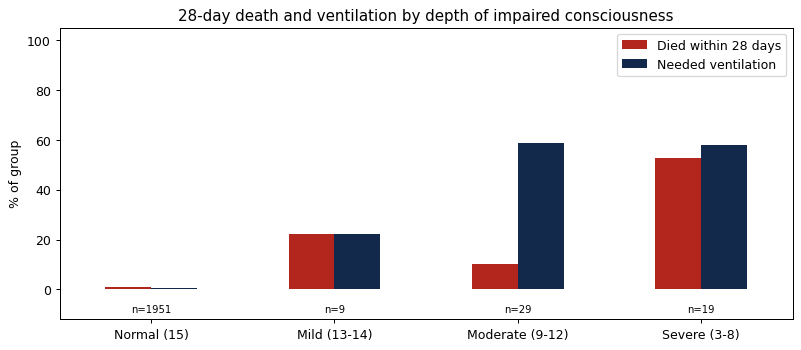

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

df["gcs_band"] = pd.cut(df["gcs"], [2, 8, 12, 14, 15], labels=["Severe (3-8)", "Moderate (9-12)", "Mild (13-14)", "Normal (15)"])
df["ventilated"] = df["respiratory_support"].notna().astype(int)
table = df.groupby("gcs_band", observed=True).agg(patients=("patient_id", "size"),
                                                  death_28d=("death_28d", lambda s: round(s.mean() * 100, 1)),
                                                  ventilated=("ventilated", lambda s: round(s.mean() * 100, 1)))
table = table.reindex(["Normal (15)", "Mild (13-14)", "Moderate (9-12)", "Severe (3-8)"])
print(table)

ax = table[["death_28d", "ventilated"]].plot.bar(figsize=(9, 4), rot=0, color=["#B3261E", "#13294B"])
for i, n in enumerate(table["patients"]):
    ax.text(i, -9, f"n={n}", ha="center", fontsize=8)
ax.set_ylabel("% of group"); ax.set_xlabel(""); ax.set_title("28-day death and ventilation by depth of impaired consciousness")
ax.legend(["Died within 28 days", "Needed ventilation"]); ax.set_ylim(-12, 105)
plt.tight_layout()
plt.show()

### How to read the chart
Pairs of bars per consciousness band. Red = % who died within 28 days, navy = % who needed ventilation; n (below each pair) is the number of patients.

### Key Insights
* Death and ventilation rise sharply with depth: **Severe (GCS ≤ 8): 52.6% died, 57.9% ventilated**, versus 1.1% and 0.6% in alert patients.
* The Mild group is tiny (9 patients), so its rates are rough.

### Prescriptive Action to be taken
* **Any GCS < 15 → critical-care outreach**; **GCS ≤ 8 → immediate ICU plus family goals-of-care discussion.**

## 21. Is length of stay linked to readmission — do short stays mean premature discharge?
### Reasoning
Under bed pressure, stays get shorter. If short stays led to more readmission, patients were going home too early.

### Metrics Biomarkers and Features used
`discharge_day` (grouped), `readmission_6m`, `readmission_28d`, regular discharges only (`hospitalization_outcome` = Alive)

### Why used
Only patients discharged alive and normally can be readmitted.

6-month readmission:
          patients  events  rate_%
stay                              
1-4 days       200      47    23.5
5-7            691     262    37.9
8-10           524     222    42.4
11-14          262     106    40.5
15+            213     108    50.7

28-day readmission:
          patients  events  rate_%
stay                              
1-4 days       200      11     5.5
5-7            691      47     6.8
8-10           524      35     6.7
11-14          262      26     9.9
15+            213      13     6.1


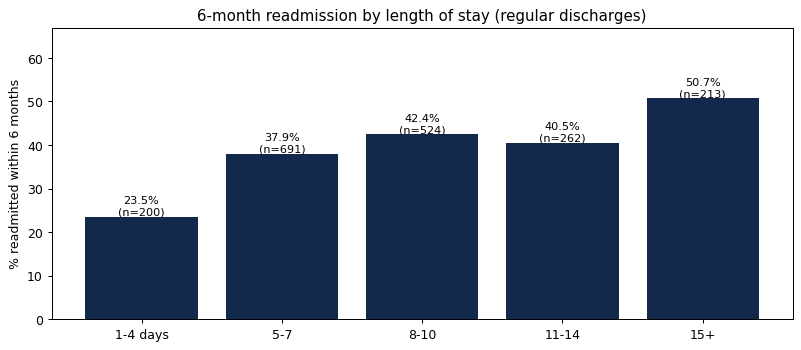

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

alive = df[df["hospitalization_outcome"] == "Alive"].copy()           # regular discharges only
alive["stay"] = pd.cut(alive["discharge_day"], [0, 4, 7, 10, 14, 500], labels=["1-4 days", "5-7", "8-10", "11-14", "15+"])
r6 = rate_table(alive, "stay", "readmission_6m"); r28 = rate_table(alive, "stay", "readmission_28d")
print("6-month readmission:"); print(r6); print("\n28-day readmission:"); print(r28)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(r6.index.astype(str), r6["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(r6["rate_%"], r6["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month readmission by length of stay (regular discharges)")
ax.set_ylabel("% readmitted within 6 months")
ax.set_ylim(0, max(r6["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is a length-of-stay group. The height is the % readmitted within 6 months; n is the number of patients.

### Key Insights
* Readmission **rises** with stay length: **23.5%** (1–4 days) → **50.7%** (15+ days).
* 28-day readmission shows no clear pattern (5.5–9.9%).
* So short stays are **not** premature discharges; long stays mark complex patients.

### Prescriptive Action to be taken
* Do not lengthen stays to prevent readmission.
* Treat a **stay of 11+ days as a readmission-risk flag** → enhanced discharge package.

## 22. Anaemia + kidney disease: does the combination drive readmission and long stays?
### Reasoning
Kidney disease causes anaemia, and anaemia strains the heart (the "cardio-renal-anaemia" syndrome).

### Metrics Biomarkers and Features used
`hemoglobin` + `gender` → WHO anaemia (< 130 g/L men, < 120 g/L women), `glomerular_filtration_rate` (< 60), `readmission_6m`, `discharge_day` (≥ 14), `death_6m`

### Why used
These are the standard definitions of anaemia and kidney impairment.

6-month readmission:
                patients  events  rate_%
group                                   
1 Neither            518     171    33.0
2 Anaemia only       527     180    34.2
3 Kidney only        240     100    41.7
4 Both               641     296    46.2

Stay 14+ days:
                patients  events  rate_%
group                                   
1 Neither            518      47     9.1
2 Anaemia only       527      56    10.6
3 Kidney only        240      44    18.3
4 Both               641     110    17.2

6-month death:
                patients  events  rate_%
group                                   
1 Neither            518      13     2.5
2 Anaemia only       527       8     1.5
3 Kidney only        240       6     2.5
4 Both               641      29     4.5


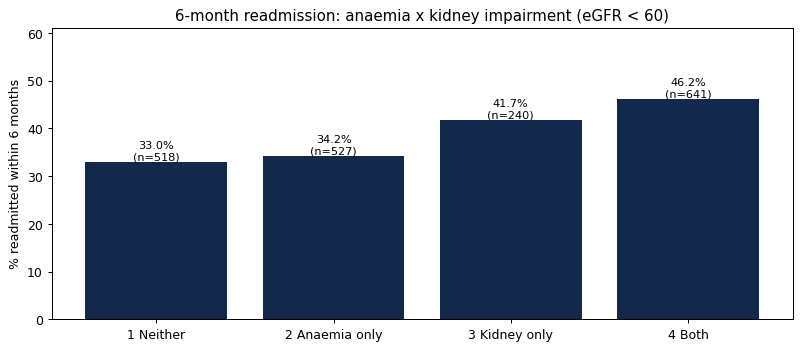

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

threshold = np.where(df["gender"] == "Male", 130, 120)                   # WHO anaemia: Hb < 130 g/L men, < 120 g/L women
anaemia = df["hemoglobin"] < threshold
ckd = df["glomerular_filtration_rate"] < 60
d = df[df["hemoglobin"].notna() & df["glomerular_filtration_rate"].notna()].copy()
d["group"] = np.select([~anaemia[d.index] & ~ckd[d.index], anaemia[d.index] & ~ckd[d.index], ~anaemia[d.index] & ckd[d.index], anaemia[d.index] & ckd[d.index]],
                       ["1 Neither", "2 Anaemia only", "3 Kidney only", "4 Both"], "")
d["long_stay"] = (d["discharge_day"] >= 14).astype(int)
readm = rate_table(d, "group", "readmission_6m"); stay = rate_table(d, "group", "long_stay"); death = rate_table(d, "group", "death_6m")
print("6-month readmission:"); print(readm); print("\nStay 14+ days:"); print(stay); print("\n6-month death:"); print(death)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(readm.index.astype(str), readm["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(readm["rate_%"], readm["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month readmission: anaemia x kidney impairment (eGFR < 60)")
ax.set_ylabel("% readmitted within 6 months")
ax.set_ylim(0, max(readm["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is one combination. The height is the % readmitted within 6 months; n is the number of patients.

### Key Insights
* Patients with **both** had the highest readmission (**46.2%** vs 33.0% with neither) and the highest 6-month death (4.5% vs 2.5%).
* **Anaemia alone added little** (34.2%); kidney impairment drives the rise.
* Long stays roughly double with kidney impairment (18.3% kidney only, 17.2% both, vs 9.1% with neither).

### Prescriptive Action to be taken
* For patients with **both**: check iron studies (IV iron helps iron-deficient HF patients) and involve nephrology.

## 23. Which medication combination should be prescribed to maximize 6-month survival?
### Reasoning
Three drug classes are proven in trials to improve HF survival: beta-blocker, ACEi/ARB and MRA (the guideline-directed therapy, GDMT). We check how many patients got them and whether survival differs.

### Metrics Biomarkers and Features used
Drug flags: oral metoprolol succinate (beta-blocker), benazepril or valsartan (ACEi/ARB), spironolactone (MRA) → number of pillars 0–3; `death_6m`; `discharge_day`, `hospitalization_outcome`

### Why used
Patients who die in the first days or leave early never get the chance to start these drugs. Comparing only eligible patients removes that bias.

All patients:
              patients  events  rate_%
gdmt_pillars                          
0                  133      13     9.8
1                  902      28     3.1
2                  696      14     2.0
3                  277       2     0.7

Eligible patients only:
              patients  events  rate_%
gdmt_pillars                          
0                  102       1     1.0
1                  820      12     1.5
2                  656       9     1.4
3                  267       2     0.7

Share on all 3 pillars: 13.8 %


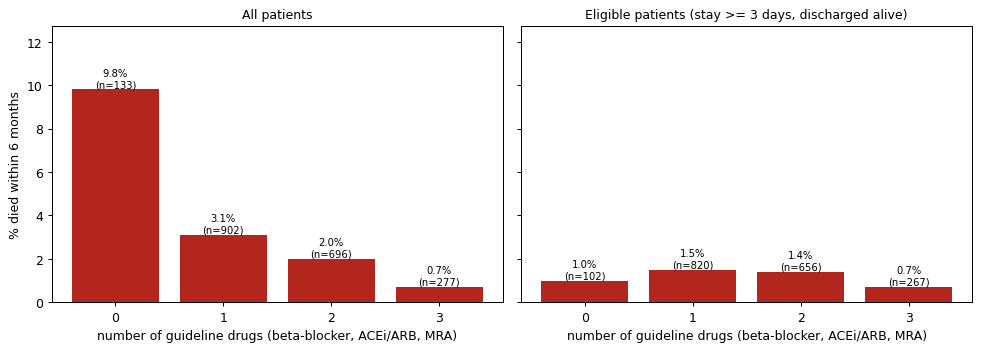

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

acei_arb = (df["drug_Benazepril_Hydrochloride_Tablet"] + df["drug_Valsartan_Dispersible_Tablet"]) > 0
df["gdmt_pillars"] = (df["drug_Metoprolol_Succinate_Sustained-Release_Tablet"] + acei_arb.astype(int) + df["drug_Spironolactone_Tablet"]).astype(int)
# Fair comparison: only patients who stayed >= 3 days and were discharged normally could have been started on these drugs
eligible = df[(df["discharge_day"] >= 3) & (df["hospitalization_outcome"] == "Alive")]
all_p = rate_table(df, "gdmt_pillars", "death_6m"); elig = rate_table(eligible, "gdmt_pillars", "death_6m")
print("All patients:"); print(all_p); print("\nEligible patients only:"); print(elig)
print("\nShare on all 3 pillars:", round((df["gdmt_pillars"] == 3).mean() * 100, 1), "%")

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for a, t, title in [(ax[0], all_p, "All patients"), (ax[1], elig, "Eligible patients (stay >= 3 days, discharged alive)")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color="#B3261E")
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title, fontsize=10); a.set_xlabel("number of guideline drugs (beta-blocker, ACEi/ARB, MRA)")
ax[0].set_ylabel("% died within 6 months"); ax[0].set_ylim(0, all_p["rate_%"].max() * 1.3)
plt.tight_layout()
plt.show()

### How to read the chart
Two panels with the same bars. Left = all patients, right = only patients who stayed at least 3 days and went home normally. The height is the % who died within 6 months for each number of guideline drugs.

### Key Insights
* **All patients:** death falls from 9.8% (no guideline drugs) to 0.7% (all three).
* **Eligible patients only:** the difference almost disappears (0.7–1.5%). The big raw gap was mostly **reverse causation**: patients who died early had no time to receive the drugs.
* Only **13.8%** received all three drugs.

### Prescriptive Action to be taken
* Prescribe **beta-blocker + ACEi/ARB + MRA** (all three pillars) to every eligible HF patient with reduced EF, based on **trial evidence**; this data cannot prove the benefit on its own.
* Measure GDMT rates only among eligible patients, and require a documented reason for each missing pillar.

## 24. Which laboratory abnormalities should trigger early intervention?
### Reasoning
Some lab results at admission signal danger in the next few weeks. Ranking them shows which should trigger immediate action.

### Metrics Biomarkers and Features used
Sodium, potassium, eGFR, urea, albumin, haemoglobin (anaemia), lactate, pH, CO₂ capacity, troponin; `death_28d`

### Why used
These are routine admission labs with standard clinical cut-offs.

                          patients_abnormal  death_28d_abnormal_%  death_28d_normal_%  difference_pts
abnormality                                                                                          
Potassium < 3.5 mmol/L                  465                   0.9                 2.1            -1.2
Troponin > 14 pg/mL                    1207                   1.5                 0.0             1.5
Anaemia (WHO)                          1205                   2.0                 1.5             0.5
Albumin < 35 g/L                        648                   2.8                 1.1             1.7
Sodium < 135 mmol/L                     387                   3.4                 1.4             2.0
Lactate > 2 mmol/L                      397                   4.5                 1.5             3.0
CO2 capacity < 18 mmol/L                181                   6.6                 1.3             5.3
eGFR < 30 mL/min                        252                   6.7                 

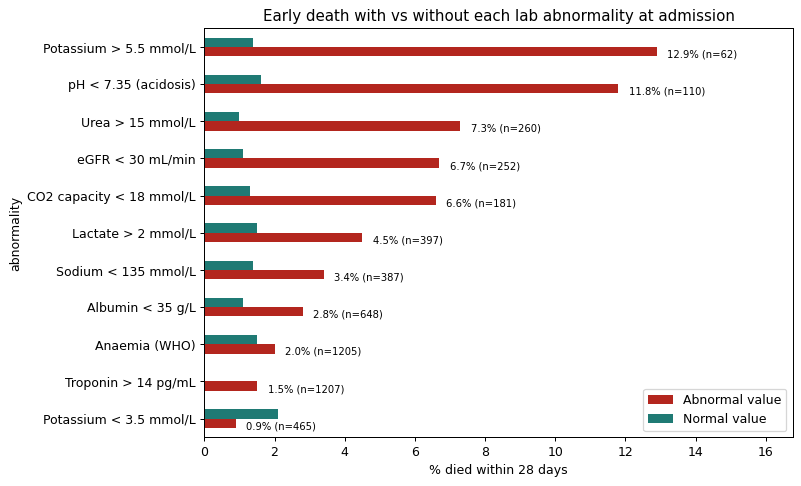

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

anaemia_cut = np.where(df["gender"] == "Male", 130, 120)
checks = {"Sodium < 135 mmol/L": (df["sodium"] < 135, df["sodium"]), "Potassium > 5.5 mmol/L": (df["potassium"] > 5.5, df["potassium"]),
          "Potassium < 3.5 mmol/L": (df["potassium"] < 3.5, df["potassium"]), "eGFR < 30 mL/min": (df["glomerular_filtration_rate"] < 30, df["glomerular_filtration_rate"]),
          "Urea > 15 mmol/L": (df["urea"] > 15, df["urea"]), "Albumin < 35 g/L": (df["albumin"] < 35, df["albumin"]),
          "Anaemia (WHO)": (df["hemoglobin"] < anaemia_cut, df["hemoglobin"]), "Lactate > 2 mmol/L": (df["lactate"] > 2, df["lactate"]),
          "pH < 7.35 (acidosis)": (df["pH"] < 7.35, df["pH"]), "CO2 capacity < 18 mmol/L": (df["CO2_capacity"] < 18, df["CO2_capacity"]),
          "Troponin > 14 pg/mL": (df["high_sensitivity_troponin"] > 14, df["high_sensitivity_troponin"])}
rows = []
for name, (flag, values) in checks.items():
    measured = values.notna()
    ab, no = df[flag & measured], df[~flag & measured]
    rows.append({"abnormality": name, "patients_abnormal": len(ab), "death_28d_abnormal_%": round(ab["death_28d"].mean() * 100, 1),
                 "death_28d_normal_%": round(no["death_28d"].mean() * 100, 1)})
t = pd.DataFrame(rows).set_index("abnormality")
t["difference_pts"] = (t["death_28d_abnormal_%"] - t["death_28d_normal_%"]).round(1)
t = t.sort_values("death_28d_abnormal_%")
print(t.to_string())

ax = t[["death_28d_abnormal_%", "death_28d_normal_%"]].plot.barh(figsize=(9, 5.5), color=["#B3261E", "#1F7A74"])
for i, (v, n) in enumerate(zip(t["death_28d_abnormal_%"], t["patients_abnormal"])):
    ax.text(v + 0.3, i - 0.2, f"{v}% (n={n})", va="center", fontsize=8)
ax.set_xlabel("% died within 28 days"); ax.set_title("Early death with vs without each lab abnormality at admission")
ax.legend(["Abnormal value", "Normal value"], loc="lower right"); ax.set_xlim(0, t["death_28d_abnormal_%"].max() * 1.3)
plt.tight_layout()
plt.show()

### How to read the chart
Each lab abnormality has two bars. Red = % died within 28 days with the abnormal value, teal = with a normal value. Rows are sorted from lowest to highest risk (highest at the top). n is the number of patients with the abnormal value.

### Key Insights
* Highest early-death risk: **potassium > 5.5** (12.9% vs 1.4%), **acidosis pH < 7.35** (11.8%), **urea > 15** (7.3%), **eGFR < 30** (6.7%) and **CO₂ capacity < 18** (6.6%).
* Low potassium was **not** linked to early death (0.9%).

### Prescriptive Action to be taken
* **Immediate senior review** for potassium > 5.5, pH < 7.35, urea > 15, eGFR < 30 or CO₂ capacity < 18 at admission.
* Lactate > 2 or sodium < 135 → closer monitoring.

## 25. Which patient groups should receive stricter medication adherence programs?
### Reasoning
Readmission often follows missed or mixed-up medicines. Groups with high readmission and complex regimens benefit most from adherence support.

### Metrics Biomarkers and Features used
`num_distinct_drugs` (10+), `dementia`, age 80+, `cci_score` (4+), `occupation` (farmer), `diabetes`, CKD; `readmission_6m`

### Why used
Readmission is the outcome adherence programmes aim to reduce.

Average 6-month readmission: 38.5 %
                        patients  readmission_6m_%
group                                             
Farmer (rural)               198              24.2
Aged 80+                     747              38.3
10+ different drugs          441              42.0
Diabetes                     466              45.7
Chronic kidney disease       474              46.2
Dementia                     115              50.4
4+ comorbidities             110              55.5


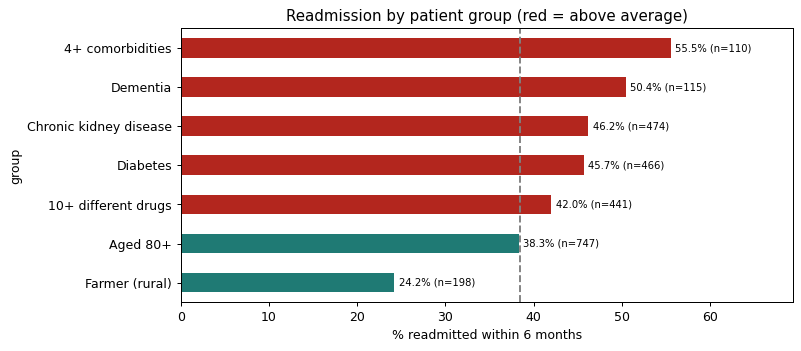

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

groups = {"10+ different drugs": df["num_distinct_drugs"] >= 10, "Dementia": df["dementia"] == 1,
          "Aged 80+": df["age_category"].isin(["79-89", "89-110"]), "4+ comorbidities": df["cci_score"] >= 4,
          "Farmer (rural)": df["occupation"] == "Farmer", "Diabetes": df["diabetes"] == 1, "Chronic kidney disease": df["moderate_to_severe_chronic_kidney_disease"] == 1}
avg = round(df["readmission_6m"].mean() * 100, 1)
rows = [{"group": g, "patients": int(m.sum()), "readmission_6m_%": round(df.loc[m, "readmission_6m"].mean() * 100, 1)} for g, m in groups.items()]
t = pd.DataFrame(rows).set_index("group").sort_values("readmission_6m_%")
print("Average 6-month readmission:", avg, "%"); print(t)

ax = t["readmission_6m_%"].plot.barh(figsize=(9, 4), color=np.where(t["readmission_6m_%"] > avg, "#B3261E", "#1F7A74"))
for i, (v, n) in enumerate(zip(t["readmission_6m_%"], t["patients"])):
    ax.text(v + 0.5, i, f"{v}% (n={n})", va="center", fontsize=8)
ax.axvline(avg, color="grey", ls="--"); ax.set_xlabel("% readmitted within 6 months")
ax.set_title("Readmission by patient group (red = above average)"); ax.set_xlim(0, t["readmission_6m_%"].max() * 1.25)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is a patient group. The length is the % readmitted within 6 months. Red bars are above the dashed average line; n is the number of patients.

### Key Insights
* Above the 38.5% average: **4+ comorbidities (55.5%)**, **dementia (50.4%)**, CKD (46.2%), diabetes (45.7%) and 10+ drugs (42.0%).
* Age 80+ alone was average (38.3%). Farmers were low (24.2%), most likely because of access, not better adherence.

### Prescriptive Action to be taken
* **Stricter adherence programme** (pharmacist review, pill organiser, carer education, follow-up call) for: **4+ comorbidities, dementia, CKD, diabetes, 10+ drugs**.

## 26. Which interventions would most reduce mortality among high-CCI patients?
### Reasoning
Patients with many comorbidities die more often. Some of their risk factors can be treated; these point to the interventions most likely to help.

### Metrics Biomarkers and Features used
Patients with `cci_score` ≥ 4; sodium, anaemia (WHO), eGFR < 30, albumin < 35, `severe_hf`, echo recorded; `death_6m`

### Why used
Each factor links to an action: correct low sodium, treat anaemia/iron, nutrition, kidney care, HF optimisation, echo.

High-comorbidity patients (4+): 110 | 6-month death: 6.4 %
                                      patients_with  death_6m_with_%  death_6m_without_%
factor                                                                                  
Low sodium (< 135)                               38              7.9                 5.6
Anaemia (WHO)                                    77              9.1                 0.0
Severe kidney impairment (eGFR < 30)             32             12.5                 3.9
Low albumin (< 35)                               52             11.5                 2.0
Severe HF (Team05 flag)                          31             19.4                 1.3
No echo recorded                                 71              7.0                 5.1


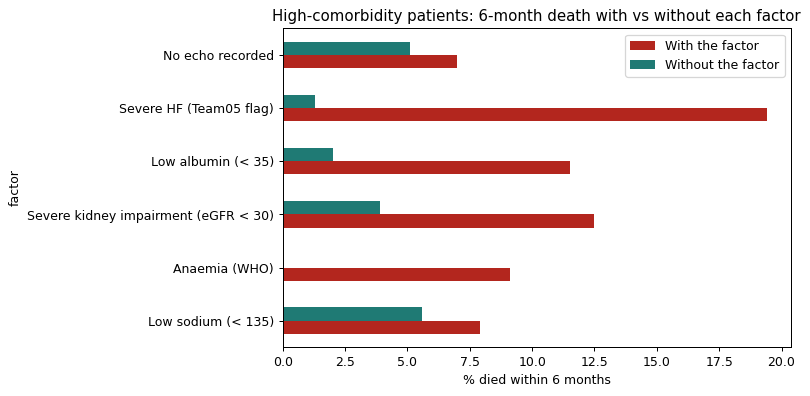

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

high = df[df["cci_score"] >= 4].copy()
anaemia_cut = np.where(high["gender"] == "Male", 130, 120)
acei_arb = (high["drug_Benazepril_Hydrochloride_Tablet"] + high["drug_Valsartan_Dispersible_Tablet"]) > 0
factors = {"Low sodium (< 135)": (high["sodium"] < 135, high["sodium"]), "Anaemia (WHO)": (high["hemoglobin"] < anaemia_cut, high["hemoglobin"]),
           "Severe kidney impairment (eGFR < 30)": (high["glomerular_filtration_rate"] < 30, high["glomerular_filtration_rate"]),
           "Low albumin (< 35)": (high["albumin"] < 35, high["albumin"]), "Severe HF (Team05 flag)": (high["severe_hf"] == 1, high["severe_hf"]),
           "No echo recorded": (high["heart_pumping_efficiency"].isna(), high["gcs"])}
rows = []
for name, (flag, values) in factors.items():
    m = values.notna()
    rows.append({"factor": name, "patients_with": int((flag & m).sum()), "death_6m_with_%": round(high.loc[flag & m, "death_6m"].mean() * 100, 1),
                 "death_6m_without_%": round(high.loc[~flag & m, "death_6m"].mean() * 100, 1)})
t = pd.DataFrame(rows).set_index("factor")
print("High-comorbidity patients (4+):", len(high), "| 6-month death:", round(high["death_6m"].mean() * 100, 1), "%"); print(t.to_string())

ax = t[["death_6m_with_%", "death_6m_without_%"]].plot.barh(figsize=(9, 4.5), color=["#B3261E", "#1F7A74"])
ax.set_xlabel("% died within 6 months"); ax.set_title("High-comorbidity patients: 6-month death with vs without each factor")
ax.legend(["With the factor", "Without the factor"])
plt.tight_layout()
plt.show()

### How to read the chart
Each factor has two bars. Red = % died within 6 months with the factor, teal = without it. A big gap means the factor matters.

### Key Insights
* 110 patients have 4+ comorbidities; 6.4% died within 6 months.
* Biggest gaps: **severe HF** (19.4% vs 1.3%), **eGFR < 30** (12.5% vs 3.9%), **low albumin** (11.5% vs 2.0%) and **anaemia** (9.1% vs 0.0%).
* Numbers are small, so treat these as priorities to act on, not exact effects.

### Prescriptive Action to be taken
* For high-CCI patients: **optimise HF treatment and decongestion**, **nephrology input when eGFR < 30**, **dietitian referral when albumin < 35**, and **iron/anaemia work-up**.
* Discuss goals of care early with the most severe patients.

## 27. Which ward resources should be prioritized for the highest-risk patients?
### Reasoning
Resources (monitoring, ventilation, ICU beds) should follow risk. We compare risk markers across admission wards.

### Metrics Biomarkers and Features used
`admission_ward`, `death_28d`, `respiratory_support` (ventilated), `gcs` < 15, `severe_hf`, `discharge_day` (bed-days)

### Why used
These show where the sickest patients and the heaviest workload are.

                patients  death_28d  ventilated  impaired_consciousness  severe_hf  bed_days
admission_ward                                                                              
Cardiology          1547        1.4         1.4                     1.7       19.7     13926
GeneralWard          265        3.0         5.3                     7.2       18.5      2649
ICU                   15       13.3        26.7                    33.3       33.3       209
Others               181        2.8         1.7                     3.3       14.9      2133

Where the 28-day deaths were admitted: {'Cardiology': 22, 'GeneralWard': 8, 'Others': 5, 'ICU': 2}


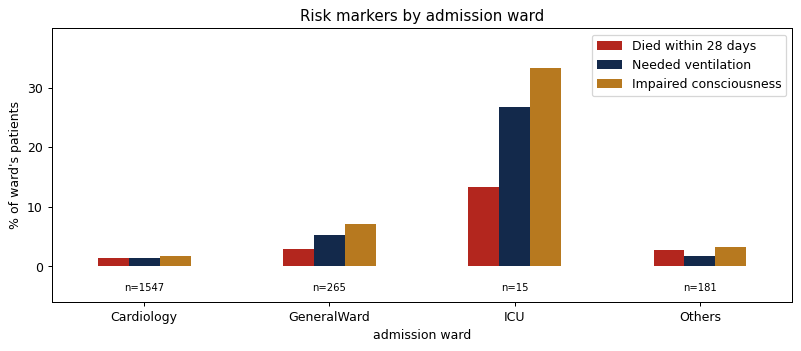

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

df["ventilated"] = df["respiratory_support"].notna().astype(int)
df["impaired"] = (df["gcs"] < 15).astype(int)
t = df.groupby("admission_ward").agg(patients=("patient_id", "size"),
                                     death_28d=("death_28d", lambda s: round(s.mean() * 100, 1)),
                                     ventilated=("ventilated", lambda s: round(s.mean() * 100, 1)),
                                     impaired_consciousness=("impaired", lambda s: round(s.mean() * 100, 1)),
                                     severe_hf=("severe_hf", lambda s: round(s.mean() * 100, 1)),
                                     bed_days=("discharge_day", "sum"))
where_deaths = df[df["death_28d"] == 1]["admission_ward"].value_counts()
print(t); print("\nWhere the 28-day deaths were admitted:", where_deaths.to_dict())

ax = t[["death_28d", "ventilated", "impaired_consciousness"]].plot.bar(figsize=(9, 4), rot=0, color=["#B3261E", "#13294B", "#B7791F"])
for i, n in enumerate(t["patients"]):
    ax.text(i, -4, f"n={n}", ha="center", fontsize=8)
ax.set_ylabel("% of ward's patients"); ax.set_xlabel("admission ward"); ax.set_ylim(-6, t[["death_28d", "ventilated", "impaired_consciousness"]].max().max() * 1.2)
ax.set_title("Risk markers by admission ward"); ax.legend(["Died within 28 days", "Needed ventilation", "Impaired consciousness"])
plt.tight_layout()
plt.show()

### How to read the chart
Groups of three bars per ward: red = % died within 28 days, navy = % ventilated, amber = % with impaired consciousness. n under each group is the number of patients.

### Key Insights
* **ICU:** highest risk per patient (13.3% 28-day death, 26.7% ventilated) but only 15 patients.
* **General Ward:** higher risk than Cardiology (3.0% death, 5.3% ventilated, 7.2% impaired consciousness).
* **Cardiology** has low risk per patient but the most patients, so most 28-day deaths still occur there (22 of 37).

### Prescriptive Action to be taken
* **General Ward:** add non-invasive ventilation capacity and early-warning monitoring for HF patients.
* **Cardiology:** risk-screen every admission, because of its volume.
* **ICU:** reserve for GCS ≤ 8 or shock (questions 1 and 20).

## 28. What preventive actions should be taken for patients with repeated admissions?
### Reasoning
A few patients come back again and again. Understanding their profile shows what prevention should target.

### Metrics Biomarkers and Features used
`visit_count` (2+ = repeated), `readmission_6m`, age, `cci_score`, `severe_hf`, `num_distinct_drugs`, `sodium`

### Why used
These describe complexity and fluid balance, the usual drivers of repeat admissions.

               patients  events  rate_%
visits                                 
1 admission        1860     708    38.1
2+ admissions       148      65    43.9

               aged_80_plus  comorbidities_4_plus  severe_hf  ten_plus_drugs  low_sodium
visits                                                                                  
1 admission            37.4                   5.4       19.4            21.2        18.9
2+ admissions          34.5                   6.8       16.9            31.1        24.3


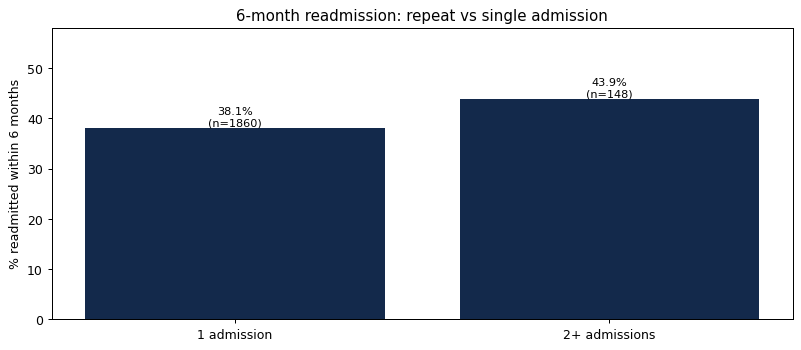

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

df["visits"] = np.where(df["visit_count"] >= 2, "2+ admissions", "1 admission")
readm = rate_table(df, "visits", "readmission_6m")
profile = df.groupby("visits").agg(aged_80_plus=("age_category", lambda s: round(s.isin(["79-89", "89-110"]).mean() * 100, 1)),
                                   comorbidities_4_plus=("cci_score", lambda s: round((s >= 4).mean() * 100, 1)),
                                   severe_hf=("severe_hf", lambda s: round(s.mean() * 100, 1)),
                                   ten_plus_drugs=("num_distinct_drugs", lambda s: round((s >= 10).mean() * 100, 1)),
                                   low_sodium=("sodium", lambda s: round((s < 135).mean() * 100, 1)))
print(readm); print(); print(profile)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(readm.index.astype(str), readm["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(readm["rate_%"], readm["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month readmission: repeat vs single admission")
ax.set_ylabel("% readmitted within 6 months")
ax.set_ylim(0, max(readm["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### How to read the chart
Two bars: single vs repeated admission. The height is the % readmitted within 6 months; n is the number of patients.

### Key Insights
* 148 patients had 2+ admissions; their 6-month readmission was 43.9% vs 38.1%.
* They more often take **10+ drugs** (31.1% vs 21.2%) and have **low sodium** (24.3% vs 18.9%), pointing to complex regimens and hard-to-control fluid.
* **Caveat:** `visit_count` may include admissions after this stay, so it partly overlaps with readmission.

### Prescriptive Action to be taken
* On the **2nd admission**: pharmacist medication review, diuretic/sodium plan, and a case manager.
* Early follow-up within 7 days, with weight monitoring at home.

## 29. What combined threshold of serum urea and serum creatinine should trigger an immediate inpatient nephrology consultation to mitigate 28-day mortality risk?
### Reasoning
Urea and creatinine both measure kidney function, but urea also rises with dehydration, bleeding and low blood flow. Looking at them together shows which combination marks danger.

### Metrics Biomarkers and Features used
`urea` (mmol/L: < 8.3 normal, 8.3–20 high, > 20 very high), `creatinine` (µmol/L: < 133 normal, 133–265 high, > 265 very high), `death_28d`

### Why used
These are standard lab bands; 28-day death is the outcome the consultation aims to reduce.

28-day death (%):
creatinine_level       Creat normal (< 133)  Creat high (133-265)  Creat very high (> 265)
urea_level                                                                                
Urea normal (< 8.3)                     0.7                   0.0                      0.0
Urea high (8.3-20)                      1.1                   2.7                      9.1
Urea very high (> 20)                  18.8                   6.1                     14.6

Patients:
creatinine_level       Creat normal (< 133)  Creat high (133-265)  Creat very high (> 265)
urea_level                                                                                
Urea normal (< 8.3)                    1011                    30                        1
Urea high (8.3-20)                      551                   225                       44
Urea very high (> 20)                    16                    66                       41


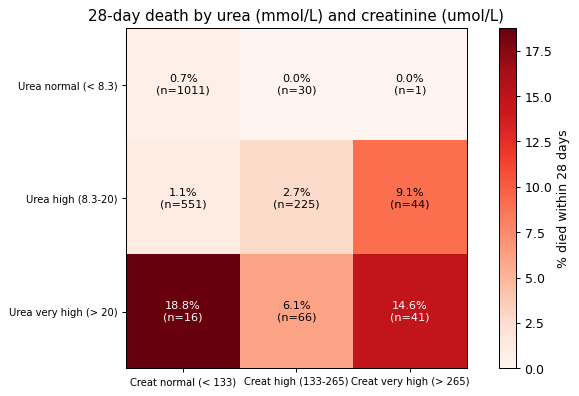

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

d = df[df["urea"].notna() & df["creatinine"].notna()].copy()
d["urea_level"] = pd.cut(d["urea"], [0, 8.3, 20, 1000], labels=["Urea normal (< 8.3)", "Urea high (8.3-20)", "Urea very high (> 20)"])
d["creatinine_level"] = pd.cut(d["creatinine"], [0, 133, 265, 5000], labels=["Creat normal (< 133)", "Creat high (133-265)", "Creat very high (> 265)"])
rate = d.pivot_table(index="urea_level", columns="creatinine_level", values="death_28d", aggfunc="mean", observed=False) * 100
count = d.pivot_table(index="urea_level", columns="creatinine_level", values="death_28d", aggfunc="size", observed=False)
print("28-day death (%):"); print(rate.round(1)); print("\nPatients:"); print(count)

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(rate.fillna(0), cmap="Reds", vmin=0)
ax.set_xticks(range(3)); ax.set_xticklabels(rate.columns, fontsize=8); ax.set_yticks(range(3)); ax.set_yticklabels(rate.index, fontsize=8)
for i in range(3):
    for j in range(3):
        n = count.iloc[i, j]
        ax.text(j, i, f"{rate.iloc[i, j]:.1f}%\n(n={n})" if n > 0 else "no patients", ha="center", va="center", fontsize=9,
                color="white" if rate.iloc[i, j] > 10 else "black")
plt.colorbar(im, fraction=0.04, label="% died within 28 days"); ax.set_title("28-day death by urea (mmol/L) and creatinine (umol/L)")
plt.tight_layout()
plt.show()

### How to read the chart
A 3×3 grid: rows = urea level, columns = creatinine level. Each cell shows the % who died within 28 days and the number of patients (n). Darker red = higher death.

### Key Insights
* Normal urea and creatinine: **0.7%** 28-day death (1011 patients).
* **Urea > 20 mmol/L** carries the highest risk at every creatinine level: 18.8% (normal creatinine, n=16), 6.1% (high), **14.6%** (very high, n=41).
* **Urea 8.3–20 with creatinine > 265:** 9.1% (n=44).
* Several cells are small, so percentages are rough.

### Prescriptive Action to be taken
* **Immediate nephrology consultation** when **urea > 20 mmol/L**, or when **creatinine > 265 µmol/L with urea > 8.3 mmol/L**.
* A high urea with normal creatinine also calls for a check for bleeding, dehydration or very low cardiac output.

## 30. Which variables are the strongest predictors of mortality?
### Reasoning
Ranking every patient characteristic by how well it separates those who died from those who survived shows what to measure first.

### Metrics Biomarkers and Features used
Every numeric patient characteristic recorded for at least 70% of patients (drugs excluded; they are treatments, not patient features); `death_6m`

### Why used
The strength score (AUC) is the chance that a patient who died has a more extreme value than a survivor: 0.5 = no signal, 1.0 = perfect. It works for any unit.

                                 AUC  strength             direction
heart_damage_level             0.760     0.760  higher = more deaths
high_sensitivity_troponin      0.709     0.709  higher = more deaths
severe_hf                      0.699     0.699  higher = more deaths
urea                           0.689     0.689  higher = more deaths
creatinine                     0.682     0.682  higher = more deaths
glomerular_filtration_rate     0.329     0.671   lower = more deaths
cystatin                       0.660     0.660  higher = more deaths
neutrophil_ratio               0.658     0.658  higher = more deaths
neutrophil_count               0.656     0.656  higher = more deaths
CO2_capacity                   0.351     0.649   lower = more deaths
basophil_ratio                 0.352     0.648   lower = more deaths
FiO2                           0.645     0.645  higher = more deaths
hydroxybutyrate_dehydrogenase  0.643     0.643  higher = more deaths
gcs                            0.3

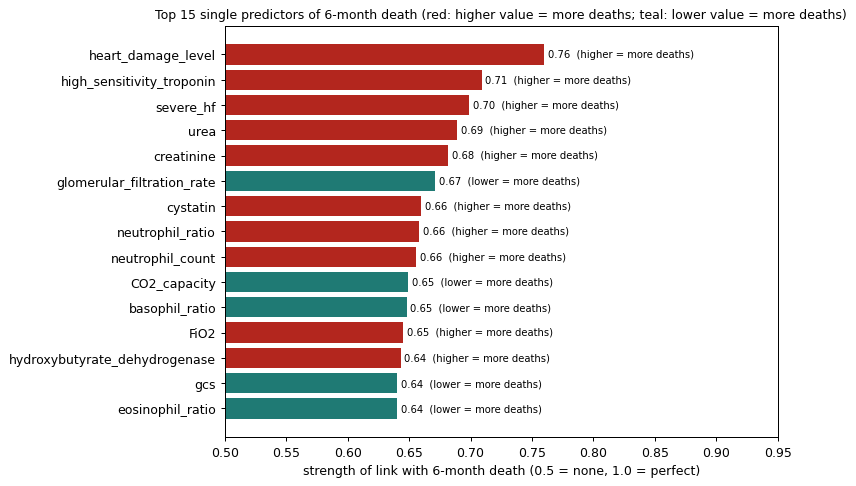

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

outcome = "death_6m"
exclude = {"patient_id", "death_28d", "death_3m", "death_6m", "readmission_28d", "readmission_3m", "readmission_6m", "death_time_days",
           "readmission_time_days", "emergency_return_6m", "emergency_return_time_days", "discharge_day", "visit_count"}
numeric = [c for c in df.select_dtypes("number").columns if c not in exclude and not c.startswith("drug_") and c != "num_distinct_drugs"
           and df[c].notna().mean() >= 0.7 and df[c].nunique() > 1]          # patient characteristics only, not treatments

def auc(values, died):
    """Chance that a random patient who died has a higher value than a random survivor (0.5 = no signal)."""
    d = pd.DataFrame({"v": values, "y": died}).dropna()
    ranks = d["v"].rank()
    n1, n0 = d["y"].sum(), (d["y"] == 0).sum()
    return (ranks[d["y"] == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

scores = pd.DataFrame({"AUC": {c: auc(df[c], df[outcome]) for c in numeric}})
scores["strength"] = (scores["AUC"] - 0.5).abs() + 0.5          # 0.5 = useless, 1.0 = perfect, whichever direction
scores["direction"] = np.where(scores["AUC"] >= 0.5, "higher = more deaths", "lower = more deaths")
top = scores.sort_values("strength", ascending=False).head(15).round(3)
print(top)

fig, ax = plt.subplots(figsize=(9, 5.5))
t = top.iloc[::-1]
ax.barh(t.index, t["strength"], color=np.where(t["direction"] == "higher = more deaths", "#B3261E", "#1F7A74"))
for i, (v, dirn) in enumerate(zip(t["strength"], t["direction"])):
    ax.text(v + 0.003, i, f"{v:.2f}  ({dirn})", va="center", fontsize=8)
ax.set_xlim(0.5, 0.95); ax.set_xlabel("strength of link with 6-month death (0.5 = none, 1.0 = perfect)")
ax.set_title("Top 15 single predictors of 6-month death (red: higher value = more deaths; teal: lower value = more deaths)", fontsize=10)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is one variable; the longer the bar, the better it separates patients who died from survivors (0.5 = no better than chance). Red = higher values mean more deaths; teal = lower values mean more deaths.

### Key Insights
* Strongest single predictors of 6-month death: **heart_damage_level** (0.76), **high_sensitivity_troponin** (0.71), **severe_hf** (0.70), **urea** (0.69) and **creatinine** (0.68).
* The list mixes **heart severity** (Killip / `heart_damage_level`, troponin), **kidney** (urea, creatinine, eGFR, cystatin), **acid–base** (CO₂ capacity) and **consciousness** (GCS).
* **Caveat:** BNP is not in the list because the cleaning removed its highest values (it is measured for only 57% of patients).

### Prescriptive Action to be taken
* Put **heart_damage_level, troponin, urea/creatinine/eGFR, CO₂ capacity and GCS** on the admission risk checklist.
* Combining one marker from each group gives a better risk score than any single marker.

## 31. Which age groups require additional post-discharge monitoring?
### Reasoning
After discharge, events include early readmission, emergency returns and death. We check whether any age group needs extra monitoring after going home.

### Metrics Biomarkers and Features used
`age_category` (grouped), patients discharged alive; `readmission_28d`, `readmission_3m`, `emergency_return_6m`, `death_6m`

### Why used
These are the post-discharge events that monitoring is meant to catch.

           patients  readmission_28d  readmission_3m  emergency_return_6m  death_6m
age_group                                                                          
<70             513              6.2            20.5                 36.3       1.4
70-79           678              6.3            27.0                 42.0       1.2
80+             699              8.2            26.8                 39.5       1.6


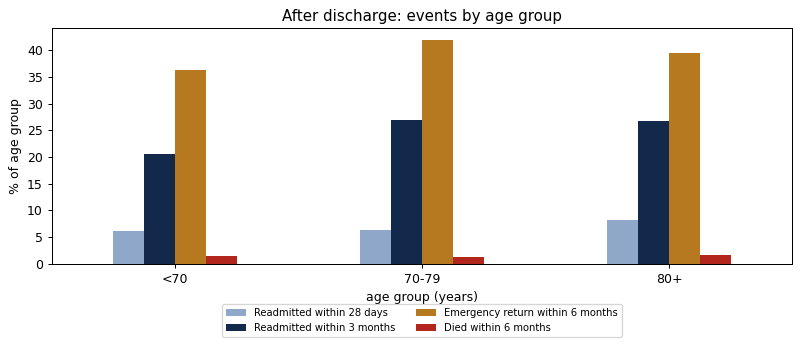

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

alive = df[df["hospitalization_outcome"] == "Alive"].copy()                # patients who went home
alive["age_group"] = alive["age_category"].map({"21-29": "<70", "29-39": "<70", "39-49": "<70", "49-59": "<70", "59-69": "<70",
                                                "69-79": "70-79", "79-89": "80+", "89-110": "80+"})
t = alive.groupby("age_group").agg(patients=("patient_id", "size"),
                                   readmission_28d=("readmission_28d", lambda s: round(s.mean() * 100, 1)),
                                   readmission_3m=("readmission_3m", lambda s: round(s.mean() * 100, 1)),
                                   emergency_return_6m=("emergency_return_6m", lambda s: round(s.mean() * 100, 1)),
                                   death_6m=("death_6m", lambda s: round(s.mean() * 100, 1))).reindex(["<70", "70-79", "80+"])
print(t)

ax = t[["readmission_28d", "readmission_3m", "emergency_return_6m", "death_6m"]].plot.bar(figsize=(9, 4), rot=0,
                                                                                          color=["#8FA7C8", "#13294B", "#B7791F", "#B3261E"])
ax.set_ylabel("% of age group"); ax.set_xlabel("age group (years)"); ax.set_title("After discharge: events by age group")
ax.legend(["Readmitted within 28 days", "Readmitted within 3 months", "Emergency return within 6 months", "Died within 6 months"], fontsize=8,
          loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

### How to read the chart
Groups of four bars per age group: light navy = readmitted within 28 days, navy = within 3 months, amber = emergency return within 6 months, red = died within 6 months. Compare the same colour across age groups.

### Key Insights
* **Aged 80+** had the highest **28-day** readmission (8.2% vs 6.2% under 70).
* **Aged 70+** had more **3-month** readmissions (27.0% and 26.8% vs 20.5%) and more emergency returns (42.0% and 39.5% vs 36.3%).
* Death after discharge was low in all groups (about 1.2–1.6%).

### Prescriptive Action to be taken
* **80+:** a check within **7–14 days** of discharge (call or visit).
* **70+:** a structured **3-month** monitoring plan (weight, symptoms, medication review).

## 32. How dangerous is high potassium, and how does it interact with spironolactone (MRA) prescribing?
### Reasoning
Potassium must stay in a narrow range. Spironolactone (an MRA) raises potassium, and failing kidneys make it worse.

### Metrics Biomarkers and Features used
`potassium` (< 3.5 low, 3.5–5.5 normal, > 5.5 high), `drug_Spironolactone_Tablet`, `glomerular_filtration_rate`, `death_6m`

### Why used
These show both the danger of high potassium and whether prescribing reacts to it.

6-month death:
                  patients  events  rate_%
potassium_level                           
Low (< 3.5)            477       9     1.9
Normal (3.5-5.5)      1458      39     2.7
High (> 5.5)            62       8    12.9

On spironolactone (%): {'Low (< 3.5)': 94.8, 'Normal (3.5-5.5)': 90.9, 'High (> 5.5)': 77.4}
Median eGFR: {'Low (< 3.5)': 76.0, 'Normal (3.5-5.5)': 62.0, 'High (> 5.5)': 27.0}


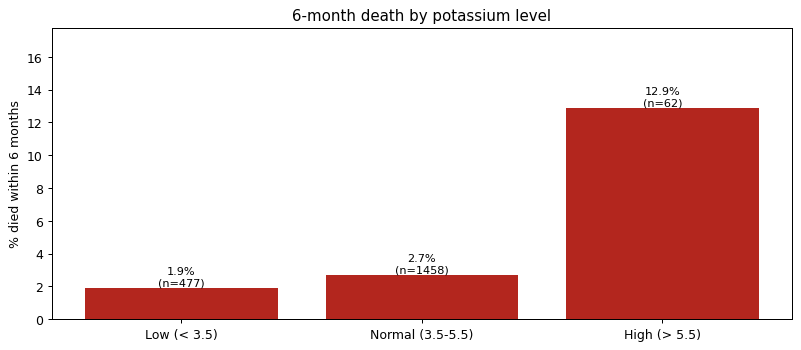

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

d = df[df["potassium"].notna()].copy()
d["potassium_level"] = pd.cut(d["potassium"], [0, 3.5, 5.5, 20], labels=["Low (< 3.5)", "Normal (3.5-5.5)", "High (> 5.5)"])
death = rate_table(d, "potassium_level", "death_6m")
spiro = d.groupby("potassium_level", observed=True)["drug_Spironolactone_Tablet"].mean().mul(100).round(1)
egfr = d.groupby("potassium_level", observed=True)["glomerular_filtration_rate"].median().round(0)
print("6-month death:"); print(death); print("\nOn spironolactone (%):", spiro.to_dict()); print("Median eGFR:", egfr.to_dict())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(death.index.astype(str), death["rate_%"], color="#B3261E")
for b, (r, n) in zip(bars, zip(death["rate_%"], death["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month death by potassium level")
ax.set_ylabel("% died within 6 months")
ax.set_ylim(0, max(death["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### How to read the chart
Each bar is a potassium level. The height is the % who died within 6 months; n is the number of patients.

### Key Insights
* High potassium (> 5.5) is rare (62 patients) but deadly: **12.9%** died within 6 months vs 2.7% with normal potassium. These patients have very poor kidneys (median eGFR 27).
* **77.4%** of patients with high potassium were still given **spironolactone** (vs 90.9% with normal potassium), which is a potential **safety issue**.

### Prescriptive Action to be taken
* **Hold or reduce spironolactone when potassium > 5.5**, and check potassium and creatinine daily until it is back in range.
* Keep spironolactone for patients with low potassium, where it helps.